# AI for Data Management - Interactive Demo

## From theory to practice: how AI strengthens the five pillars of data management

In this notebook we demonstrate how **Artificial Intelligence** can be applied to the five core themes of data management:

| # | Theme | What do we show? |
|---|-------|-----------------|
| 1 | **Data Governance** | Automatic classification of sensitive data, PII detection, policy suggestions |
| 2 | **Data Quality** | Anomaly detection, fuzzy duplicate detection, automated quality scores |
| 3 | **Data Lineage** | Automatically track and visualize data transformations |
| 4 | **Metadata Management** | Auto-profiling, smart tagging, automatically generated data catalog |
| 5 | **Master Data Management** | Entity resolution, golden record creation, automated standardization |

We work with a **synthetic dataset** that is intentionally messy - just like real-world data. Then we show how AI helps bring order.

> This notebook supports a lecture on AI and Data Management.

---
## Step 0: Install and import required libraries

We start by importing all required Python libraries. If a package is missing, it will be installed automatically.

In [96]:
# === Install required packages ===
# All packages already installed in kernel - skip installation

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
from datetime import datetime, timedelta
from collections import Counter

from faker import Faker
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from fuzzywuzzy import fuzz, process
import networkx as nx

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

fake = Faker('nl_NL')
Faker.seed(42)
np.random.seed(42)

print("OK - All libraries loaded successfully.")

OK - All libraries loaded successfully.


## 🗣️ Natural Language Processing (NLP) — Why Text Matters

Many data quality issues hide in **unstructured text**—comments, notes, feedback fields. To analyze them effectively, we need NLP.

### What is NLP?
**Natural Language Processing** allows machines to understand and work with human language. Instead of treating text as a black box, NLP breaks it down into meaningful pieces.

### Key NLP Techniques Used Here:

| Technique | What | Example |
|-----------|------|---------|
| **Tokenization** | Split text into words/sentences | "The client's IBAN is NL91 ABCD" → ["The", "client's", "IBAN", "is", "NL91", "ABCD"] |
| **Stemming** | Reduce words to root form | "running", "runs", "ran" → all become "run" |
| **Stopwords** | Remove common words (the, and, or, etc.) | "The client is important" → ["client", "important"] |
| **Keyword Extraction** | Find meaningful words in text | Extract PII patterns, spam phrases, sentiment terms |

### Why These Tools Matter for Data Governance

1. **PII Detection in Comments**: Comments often hide sensitive data like phone numbers, IBANs, or BSNs
2. **Duplicate Detection**: Different spellings of names (Jan vs J., Amsterdam vs AMS) can be normalized
3. **Text Similarity**: Find near-duplicate records despite slight variations
4. **Pattern Recognition**: Identify consistent issues across free-text fields

### Tools We'll Use: NLTK

**NLTK** (Natural Language Toolkit) is the industry standard for Python NLP:
- **Tokenizer** (punkt): Splits text into words/sentences
- **Stemmer** (Snowball): Reduces words to root form (language-aware)
- **Stopwords**: Pre-built lists of common words for multiple languages

Let's initialize these tools:

In [97]:
# === Natural Language Processing Setup (Python 3.14 compatible) ===
import sys
import warnings
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem.snowball import SnowballStemmer

print("Setting up NLP tools for Python 3.14...")
print(f"Python version: {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

# Download required NLTK data
print("\nDownloading NLTK data (Dutch language support)...")
try:
    nltk.download('punkt_tab', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    print("✓ NLTK data downloaded successfully")
except Exception as e:
    print(f"⚠️  Warning: {e}")

# Initialize Dutch language tools
try:
    dutch_stopwords = set(stopwords.words('dutch'))
    stemmer = SnowballStemmer('dutch')
    
    # Create helper functions for NLP tasks
    def tokenize_and_stem(text):
        """Tokenize text and apply stemming."""
        tokens = word_tokenize(text.lower(), language='dutch')
        return [stemmer.stem(token) for token in tokens if token.isalnum()]
    
    def remove_stopwords(tokens):
        """Remove Dutch stopwords from token list."""
        return [token for token in tokens if token not in dutch_stopwords]
    
    def extract_keywords(text, remove_stops=True):
        """Extract keywords from Dutch text."""
        tokens = tokenize_and_stem(text)
        if remove_stops:
            tokens = remove_stopwords(tokens)
        return tokens
    
    NLP_AVAILABLE = True
    print("✓ Dutch NLP tools initialized successfully")
    print(f"  - Tokenizer: English/Dutch (NLTK punkt_tab)")
    print(f"  - Stemmer: Snowball (Dutch)")
    print(f"  - Stopwords: {len(dutch_stopwords)} Dutch stopwords loaded")
    
except Exception as e:
    print(f"✗ NLP setup failed: {e}")
    NLP_AVAILABLE = False

print(f"\nNLP Status: {'AVAILABLE' if NLP_AVAILABLE else 'NOT AVAILABLE'}")


Setting up NLP tools for Python 3.14...
Python version: 3.14.0

✓ NLTK data downloaded successfully
✓ Dutch NLP tools initialized successfully
  - Tokenizer: English/Dutch (NLTK punkt_tab)
  - Stemmer: Snowball (Dutch)
  - Stopwords: 101 Dutch stopwords loaded

NLP Status: AVAILABLE


## NLP Tools Ready!

✓ **NLTK is now ready!** We're using the Snowball stemmer and NLTK tokenizer for Dutch language processing.

**What's available:**
- **Tokenization**: Break text into words and sentences (Dutch language support)
- **Stemming**: Reduce words to their root form
- **Stopword removal**: Filter out common Dutch words
- **Keyword extraction**: Get meaningful words from Dutch text

**Helper functions** available throughout the notebook:
- `tokenize_and_stem(text)` - Tokenize and stem Dutch text
- `remove_stopwords(tokens)` - Filter out Dutch stopwords  
- `extract_keywords(text)` - Extract keywords from Dutch text

These will be used in the **Data Quality** and **Metadata Management** sections for text analysis on the messy dataset.


---
## Step 1: Create a synthetic dataset (with intentional issues)

We generate a realistic customer/order dataset with about 1000 rows. We intentionally add typical data problems you see in practice:

- Duplicates with small variations (e.g., "Jan de Vries" vs "J. de Vries")
- Missing values in key fields
- Invalid email addresses and phone numbers
- Typos in city names ("Amstterdam", "Utreccht")
- Outliers in amounts (negative orders, extreme values)
- Inconsistent date formats (DD-MM-YYYY vs YYYY/MM/DD)
- BSN numbers and IBAN hidden in comment fields (PII leakage)
- Inconsistent capitalization and mixed language

In [52]:
# === DATASET GENERATION with intentional data quality issues ===
n_records = 350  # Smaller base for more visible duplicates in sample

# Cities - correct reference list
reference_cities = ['Amsterdam', 'Rotterdam', 'Utrecht', 'Den Haag', 'Eindhoven',
                    'Groningen', 'Tilburg', 'Almere', 'Breda', 'Nijmegen',
                    'Arnhem', 'Haarlem', 'Leiden', 'Maastricht', 'Zwolle',
                    'Apeldoorn', 'Enschede', 'Amersfoort', 'Delft', 'Delphi']

# Typos for 15% of city names
cities_with_typos = {
    'Amsterdam': ['Amstterdam', 'amsterdam', 'AMSTERDAM', 'Amersterdam'],
    'Rotterdam': ['Roterdam', 'rotterdam', 'ROTTERDAM', 'Rottterdam'],
    'Utrecht': ['Utreccht', 'utrecht', 'UTRECHT', 'Utrect'],
    'Den Haag': ['den haag', 'Den haag', 'DEN HAAG', "'s-Gravenhage"],
    'Eindhoven': ['Eindhovn', 'eindhoven', 'EINDHOVEN', 'Eindhovne'],
    'Groningen': ['Gronnigen', 'groningen', 'GRONINGEN'],
    'Maastricht': ['Maastrich', 'maastricht', 'MAASTRICHT'],
}

print('⚠️  GENERATING SYNTHETIC DATA WITH INTENTIONAL QUALITY ISSUES')
print('=' * 70)
print('Injecting the following problems:')
print('  • ~15% city names: typos & inconsistent capitalization')
print('  • ~10% email addresses: invalid format (missing @, spaces, double dots)')
print('  • ~9% phone numbers: malformed (too short, letters, wrong prefix)')
print('  • ~5% order amounts: extreme outliers (negative, zero, huge values)')
print('  • 6-8% missing values per column (email, phone, city, postal_code, DOB)')
print('  • PII leakage: BSN, IBAN, addresses, phone numbers in comments')
print('  • ~100+ duplicate customers with name variations (detectable via fuzzy matching)')
print('  • Date format inconsistencies (multiple formats mixed)')
print('=' * 70 + '\n')

# Generate base data
records = []
pool_for_duplicates = []  # Store some records to create realistic duplicates

for i in range(n_records):
    first_name = fake.first_name()
    last_name = fake.last_name()
    city = np.random.choice(reference_cities)
    
    # 15% chance of typo or inconsistent capitalization in city name
    if city in cities_with_typos and np.random.random() < 0.15:
        city = np.random.choice(cities_with_typos[city])
    
    # Phone numbers with 9% intentional malformations
    phone_formats = [
        f"06-{fake.numerify('########')}",  # Valid format
        f"06{fake.numerify('########')}",   # Missing dash
        f"+31 6 {fake.numerify('#### ####')}",  # Valid format
        f"0{np.random.choice([10,20,30,50,70])}-{fake.numerify('#######')}",
        f"06 {fake.numerify('## ## ## ##')}",
    ]
    phone = np.random.choice(phone_formats)
    
    # 9% malformed phone numbers
    if np.random.random() < 0.09:
        phone = np.random.choice([
            '06 123',           # Too short
            '06-ABCD1234',      # Contains letters
            '004912345678',     # Wrong prefix
            '0612 345',         # Inconsistent spacing
            '06/1234567890',    # Wrong separator
        ])
    
    # Email addresses - 10% invalid
    email = f"{first_name.lower()}.{last_name.lower()}@{np.random.choice(['gmail.com', 'hotmail.nl', 'outlook.com', 'bedrijf.nl', 'xs4all.nl'])}"
    if np.random.random() < 0.10:
        email = np.random.choice([
            f"{first_name}@",
            f"{first_name}@.com",
            f"@{last_name}.nl",
            f"{first_name} {last_name}@gmail.com",
            f"{first_name}..{last_name}@mail.nl",
            f"{first_name}.{last_name}",  # Missing @domain
        ])
    
    # Order dates in inconsistent formats
    order_date = fake.date_between(start_date='-2y', end_date='today')
    date_formats = ['%d-%m-%Y', '%Y/%m/%d', '%d/%m/%Y', '%Y-%m-%d', '%d %b %Y', '%d.%m.%Y']
    date_str = order_date.strftime(np.random.choice(date_formats))
    
    # Order amounts - 5% extreme outliers
    amount = round(np.random.lognormal(mean=4, sigma=1), 2)
    if np.random.random() < 0.05:
        amount = round(np.random.choice([-500, 99999, 0.01, 150000, -1200]), 2)
    
    # PII data sometimes leaked into comments
    bsn = fake.numerify('#########')
    iban = fake.iban()
    
    # Comments with intentional PII leakage
    comment_options = [
        f"Standard delivery to {city}",
        f"Customer prefers callback at {phone}",
        f"Customer BSN: {bsn} - verification needed",
        f"Payment via {iban}",
        f"Urgent delivery requested",
        f"Customer prefers English communication",
        f"Return request submitted",
        f"Address verified",
        "",
        np.nan,
        f"Date of birth: {fake.date_of_birth(minimum_age=18, maximum_age=90).strftime('%d-%m-%Y')}",
        f"Contact person: {fake.name()}, tel: {fake.phone_number()}",
    ]
    comment = np.random.choice(comment_options)
    
    # Inconsistent name capitalization (first/last names should be proper case)
    if np.random.random() < 0.08:
        first_name = first_name.upper()
    elif np.random.random() < 0.05:
        first_name = first_name.lower()
    
    record = {
        'customer_id': f"KL-{1000 + i}",
        'first_name': first_name,
        'last_name': last_name,
        'email': email,
        'phone': phone,
        'street': fake.street_name(),
        'house_number': fake.building_number(),
        'postal_code': fake.postcode(),
        'city': city,
        'date_of_birth': fake.date_of_birth(minimum_age=18, maximum_age=90).strftime('%d-%m-%Y'),
        'order_id': f"ORD-{10000 + i}",
        'order_date': date_str,
        'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Furniture', 'Sports', 'Garden', 'Food']),
        'amount': amount,
        'quantity': max(1, int(np.random.exponential(2))),
        'payment_method': np.random.choice(['iDEAL', 'Credit Card', 'PayPal', 'Bank Transfer', 'Klarna']),
        'comments': comment,
    }
    records.append(record)
    
    # Store 30% of records as candidates for creating duplicates
    if i % 3 == 0 and len(pool_for_duplicates) < 30:
        pool_for_duplicates.append(record.copy())

df = pd.DataFrame(records)

# === CREATE CLEVER DUPLICATES (name variations that will score 70-85 on fuzzy match) ===
duplicate_names = ['John Smith', 'Maria Garcia', 'Hans Mueller', 'Anna Kowalski', 
                   'Jean Dupont', 'Carlos Rodriguez', 'Sofia Rossi', 'Yuki Tanaka',
                   'Emma Johnson', 'Pierre Martin', 'Lucia Bianchi', 'Olaf Jensen']

# Use fixed duplicate pool to ensure they appear together
duplicates = []
dup_counter = 0
for idx, base_name in enumerate(duplicate_names):
    base_first, base_last = base_name.split()
    base_street = fake.street_name()
    
    # Create 7-8 variations of each person (intentional customer re-entry)
    num_variations = np.random.randint(7, 9)
    for var in range(num_variations):
        variation_type = var % 6
        
        if variation_type == 0:
            # Typo in first name
            first_var = base_first[:-1] if len(base_first) > 1 else base_first
            last_var = base_last
        elif variation_type == 1:
            # Typo in last name
            first_var = base_first
            last_var = base_last[:-1] if len(base_last) > 1 else base_last
        elif variation_type == 2:
            # Capitalization variation
            first_var = base_first.lower()
            last_var = base_last.lower()
        elif variation_type == 3:
            # Space in name
            first_var = base_first + ' '
            last_var = base_last
        elif variation_type == 4:
            # Middle initial
            first_var = base_first[0] + '.'
            last_var = base_last
        else:
            # Minor letter swap
            if len(base_first) > 1:
                first_list = list(base_first)
                first_list[0], first_list[1] = first_list[1], first_list[0]
                first_var = ''.join(first_list)
            else:
                first_var = base_first
            last_var = base_last
        
        dup = {
            'customer_id': f"KL-{2000 + dup_counter}",
            'first_name': first_var,
            'last_name': last_var,
            'email': f"{first_var.lower().replace(' ', '')}.{last_var.lower()}@gmail.com",
            'phone': f"06-{np.random.randint(10000000, 99999999)}",
            'street': base_street,  # SAME street = detectable duplicate
            'house_number': fake.building_number(),
            'postal_code': fake.postcode(),
            'city': np.random.choice(reference_cities),
            'date_of_birth': fake.date_of_birth(minimum_age=18, maximum_age=90).strftime('%d-%m-%Y'),
            'order_id': f"ORD-{20000 + dup_counter}",
            'order_date': fake.date_between(start_date='-1y').strftime('%d-%m-%Y'),
            'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Furniture', 'Sports', 'Garden', 'Food']),
            'amount': round(np.random.lognormal(mean=4, sigma=1), 2),
            'quantity': max(1, int(np.random.exponential(2))),
            'payment_method': np.random.choice(['iDEAL', 'Credit Card', 'PayPal', 'Bank Transfer', 'Klarna']),
            'comments': '',
        }
        duplicates.append(dup)
        dup_counter += 1

df = pd.concat([df, pd.DataFrame(duplicates)], ignore_index=True)

# === ADD MISSING VALUES (6-8% per column) ===
missing_cols = ['email', 'phone', 'city', 'postal_code', 'date_of_birth']
for col in missing_cols:
    missing_pct = np.random.uniform(0.06, 0.08)
    mask = np.random.random(len(df)) < missing_pct
    df.loc[mask, col] = np.nan

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✓ Dataset created: {len(df)} rows × {len(df.columns)} columns")
print(f"  • {len(duplicates)} intentional duplicate records (with {len(duplicate_names)} base customers)")
print(f"  • Duplicates use SAME STREET to ensure fuzzy match detection")
print(f"  • Name variations: typos, capitalization, spacing, initials")
print(f"  • Missing values: {df.isnull().sum().sum()} cells across columns")
print(f"  • Date format inconsistencies: Multiple formats mixed")
print(f"\n💡 This intentionally messy dataset is what real-world data looks like!")
print("   Now we use AI to automatically detect and report all these issues.\n")

df.head(10)

⚠️  GENERATING SYNTHETIC DATA WITH INTENTIONAL QUALITY ISSUES
Injecting the following problems:
  • ~15% city names: typos & inconsistent capitalization
  • ~10% email addresses: invalid format (missing @, spaces, double dots)
  • ~9% phone numbers: malformed (too short, letters, wrong prefix)
  • ~5% order amounts: extreme outliers (negative, zero, huge values)
  • 6-8% missing values per column (email, phone, city, postal_code, DOB)
  • PII leakage: BSN, IBAN, addresses, phone numbers in comments
  • ~100+ duplicate customers with name variations (detectable via fuzzy matching)
  • Date format inconsistencies (multiple formats mixed)

✓ Dataset created: 441 rows × 17 columns
  • 91 intentional duplicate records (with 12 base customers)
  • Duplicates use SAME STREET to ensure fuzzy match detection
  • Name variations: typos, capitalization, spacing, initials
  • Missing values: 144 cells across columns
  • Date format inconsistencies: Multiple formats mixed

💡 This intentionally mess

,customer_id,first_name,last_name,email,phone,street,house_number,postal_code,city,date_of_birth,order_id,order_date,product_category,amount,quantity,payment_method,comments
0,KL-1078,Lizzy,Kramer,lizzy.kramer@outlook.com,+31 6 9330 9286,Esméehof,16,2677 KJ,Amersfoort,13-03-1990,ORD-10078,19 Aug 2024,Clothing,45.22,1,Credit Card,Customer BSN: 697187346 - verificati...
1,KL-2089,lOaf,Jensen,loaf.jensen@gmail.com,06-87179535,Thijnlaan,7,NaN,Amsterdam,15-01-1978,ORD-20089,02-08-2025,Food,71.58,2,Klarna,
2,KL-1152,Mats,van Suinvorde,Mats@.com,NaN,Twansingel,808,8403LL,Groningen,01-01-1952,ORD-10152,12-12-2024,Sports,20.07,1,Bank Transfer,
3,KL-1281,Luuk,Backer,luuk.backer@xs4all.nl,0600020860,Juliettepad,9,9375SH,Tilburg,12-08-1974,ORD-10281,2025/02/18,Sports,43.40,1,iDEAL,Return request submitted
4,KL-2044,Carlo,Rodriguez,carlo.rodriguez@gmail.com,06-17452445,Johannessteeg,503,8976IU,Haarlem,NaN,ORD-20044,08-12-2025,Electronics,25.00,1,Klarna,
5,KL-2046,Sofi,Rossi,sofi.rossi@gmail.com,06-93249340,Bastiaanstraat,5,1616DU,Leiden,19-12-1936,ORD-20046,25-04-2025,Food,22.28,2,Bank Transfer,
6,KL-1237,Helena,Schenk,NaN,0678185844,Miloring,3,8371 QC,Amsterdam,26-12-1965,ORD-10237,08-08-2024,Sports,8.33,1,Bank Transfer,Urgent delivery requested
7,KL-1117,Ecrin,Bouwhuisen,ecrin.bouwhuisen@bedrijf.nl,06-04986488,Felixring,0,NaN,Maastricht,10-01-1960,ORD-10117,2025-09-26,Electronics,12.99,2,Credit Card,Customer prefers English communication
8,KL-2056,Yuki,Tanaka,yuki.tanaka@gmail.com,06-60598181,Tesspad,0,5310JK,Den Haag,NaN,ORD-20056,29-06-2025,Clothing,159.05,1,Klarna,
9,KL-2048,sofia,rossi,sofia.rossi@gmail.com,06-44457878,Bastiaanstraat,17,2824 JT,Groningen,22-07-2002,ORD-20048,01-06-2025,Garden,34.15,1,Klarna,


---
## Step 2: Explore the raw data

Let us first look at what we have - and what is wrong with it. This is the situation *without* AI support.

In [53]:
# === DATA EXPLORATION ===
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nRows:    {len(df)}")
print(f"Columns: {len(df.columns)}")

print("\nData types:")
print(df.dtypes.to_string())

print("\n\nMissing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0].to_string())

print("\n\nTop 15 city names (note the variations):")
print(df['city'].value_counts().head(15).to_string())

print("\n\nOrder amount statistics:")
print(df['amount'].describe().to_string())

DATASET OVERVIEW

Rows:    441
Columns: 17

Data types:
customer_id          object
first_name           object
last_name            object
email                object
phone                object
street               object
house_number         object
postal_code          object
city                 object
date_of_birth        object
order_id             object
order_date           object
product_category     object
amount              float64
quantity              int64
payment_method       object
comments             object


Missing values per column:
               Missing  Percent
email               24      5.4
phone               24      5.4
postal_code         32      7.3
city                27      6.1
date_of_birth       37      8.4


Top 15 city names (note the variations):
city
Leiden        35
Zwolle        30
Arnhem        26
Amersfoort    23
Utrecht       22
Den Haag      21
Haarlem       21
Maastricht    21
Delft         20
Enschede      19
Breda         19
Delphi      

---
# Theme 1: Data Governance

> "Data Governance is about organizing responsibilities, policies, and processes around data."

### What can rules-based classification do here?
- **Automatic classification** of columns as personal data (PII), financial, or public — using column name matching and regex patterns
- **Policy suggestions** based on detected sensitivity levels
- **GDPR compliance scanning** — automatically scanning free-text fields using regex for phone numbers, IBANs, BSNs, and emails

> ⚠️ **Be honest about the tech**: The column classifier below uses hardcoded keyword lists and `if/elif` rules — not machine learning. That is perfectly fine for many governance tasks! The ML comes later (section 1.2) when we train a LogisticRegression classifier on comment data.

In [54]:
# === DATA GOVERNANCE: Automatic Data Classification ===

def classify_column(column_name, values):
    """
    Rule-based classification of a column based on:
    - Column name (semantic analysis)
    - Pattern recognition in values
    - Statistical features
    """
    column_name_lower = column_name.lower()
    values_str = values.dropna().astype(str)
    sample = values_str.head(100)
    
    classification = {
        'column': column_name,
        'type_detection': 'unknown',
        'sensitivity': 'public',
        'gdpr_relevant': False,
        'recommended_access': 'open',
        'confidence': 0.0,
        'reason': ''
    }
    
    # === Rule-based + pattern recognition (simulates ML classification) ===
    
    # PII: Names
    name_keywords = ['naam', 'name', 'voornaam', 'achternaam', 'first_name', 'last_name', 'contactpersoon']
    if any(kw in column_name_lower for kw in name_keywords):
        classification.update({
            'type_detection': 'Person name',
            'sensitivity': 'confidential',
            'gdpr_relevant': True,
            'recommended_access': 'restricted',
            'confidence': 0.95,
            'reason': 'Column name contains a name-related keyword'
        })
    
    # PII: Email
    elif 'email' in column_name_lower or 'mail' in column_name_lower:
        classification.update({
            'type_detection': 'Email address',
            'sensitivity': 'confidential',
            'gdpr_relevant': True,
            'recommended_access': 'restricted',
            'confidence': 0.97,
            'reason': 'Email addresses detected'
        })
    
    # PII: Phone
    elif any(kw in column_name_lower for kw in ['telefoon', 'phone', 'tel', 'mobiel']):
        classification.update({
            'type_detection': 'Phone number',
            'sensitivity': 'confidential',
            'gdpr_relevant': True,
            'recommended_access': 'restricted',
            'confidence': 0.94,
            'reason': 'Phone number pattern recognized'
        })
    
    # PII: Date of birth
    elif any(kw in column_name_lower for kw in ['geboorte', 'birth', 'dob', 'leeftijd']):
        classification.update({
            'type_detection': 'Date of birth',
            'sensitivity': 'confidential',
            'gdpr_relevant': True,
            'recommended_access': 'restricted',
            'confidence': 0.96,
            'reason': 'Date of birth is a special personal attribute'
        })
    
    # Address data
    elif any(kw in column_name_lower for kw in ['straat', 'adres', 'address', 'huisnummer', 'postcode', 'stad', 'city', 'woonplaats']):
        classification.update({
            'type_detection': 'Address data',
            'sensitivity': 'internal',
            'gdpr_relevant': True,
            'recommended_access': 'restricted',
            'confidence': 0.90,
            'reason': 'Address information can identify individuals'
        })
    
    # Financial data
    elif any(kw in column_name_lower for kw in ['bedrag', 'amount', 'prijs', 'betaal', 'iban', 'rekening']):
        classification.update({
            'type_detection': 'Financial data',
            'sensitivity': 'confidential',
            'gdpr_relevant': False,
            'recommended_access': 'restricted',
            'confidence': 0.88,
            'reason': 'Financial information requires protection'
        })
    
    # ID fields
    elif any(kw in column_name_lower for kw in ['_id', 'customer_id', 'order_id', 'nummer']):
        classification.update({
            'type_detection': 'Identifier',
            'sensitivity': 'internal',
            'gdpr_relevant': False,
            'recommended_access': 'internal',
            'confidence': 0.85,
            'reason': 'Internal identifier key'
        })
    
    # Free text fields - extra scan for PII leakage
    elif values_str.str.len().mean() > 20:
        pii_patterns = {
            'BSN': r'\b\d{9}\b',
            'IBAN': r'\b[A-Z]{2}\d{2}[A-Z]{4}\d{10}\b',
            'phone': r'\b0[1-9][0-9\-\s]{7,12}\b',
            'email': r'\b[\w.-]+@[\w.-]+\.\w+\b',
            'date_of_birth': r'\b\d{2}-\d{2}-\d{4}\b',
        }
        found_pii = []
        for pii_type, pattern in pii_patterns.items():
            matches = values_str.str.contains(pattern, regex=True, na=False).sum()
            if matches > 0:
                found_pii.append(f"{pii_type} ({matches}x)")
        
        if found_pii:
            classification.update({
                'type_detection': 'Free text with PII leakage',
                'sensitivity': 'CRITICAL',
                'gdpr_relevant': True,
                'recommended_access': 'strictly restricted',
                'confidence': 0.92,
                'reason': f"PII found: {', '.join(found_pii)}"
            })
        else:
            classification.update({
                'type_detection': 'Free text',
                'sensitivity': 'internal',
                'gdpr_relevant': False,
                'recommended_access': 'internal',
                'confidence': 0.70,
                'reason': 'Free text field without detected PII'
            })
    
    # Other categories
    else:
        n_unique = values.nunique()
        if n_unique < 10:
            classification.update({
                'type_detection': 'Categorical',
                'sensitivity': 'public',
                'gdpr_relevant': False,
                'recommended_access': 'open',
                'confidence': 0.80,
                'reason': f"Categorical variable ({n_unique} unique values)"
            })
    
    return classification

# Run classification on all columns
print('DATA GOVERNANCE - Automatic Data Classification')
print('=' * 70)

classifications = [classify_column(col, df[col]) for col in df.columns]
df_class = pd.DataFrame(classifications)

# Color coding for display
def highlight_sensitivity(val):
    colors = {
        'CRITICAL': 'background-color: #ff4444; color: white; font-weight: bold',
        'confidential': 'background-color: #ff8c00; color: white',
        'internal': 'background-color: #ffd700; color: black',
        'public': 'background-color: #90ee90; color: black',
    }
    return colors.get(val, '')

styled = df_class[['column', 'type_detection', 'sensitivity', 'gdpr_relevant', 'recommended_access', 'confidence', 'reason']]\
    .style.applymap(highlight_sensitivity, subset=['sensitivity'])\
    .format({'confidence': '{:.0%}'})\
    .set_caption('AI Data Classification - Governance Report')

styled

DATA GOVERNANCE - Automatic Data Classification


,column,type_detection,sensitivity,gdpr_relevant,recommended_access,confidence,reason
0,customer_id,Identifier,internal,False,internal,85%,Internal identifier key
1,first_name,Person name,confidential,True,restricted,95%,Column name contains a name-related keyword
2,last_name,Person name,confidential,True,restricted,95%,Column name contains a name-related keyword
3,email,Email address,confidential,True,restricted,97%,Email addresses detected
4,phone,Phone number,confidential,True,restricted,94%,Phone number pattern recognized
5,street,unknown,public,False,open,0%,
6,house_number,unknown,public,False,open,0%,
7,postal_code,unknown,public,False,open,0%,
8,city,Address data,internal,True,restricted,90%,Address information can identify individuals
9,date_of_birth,Date of birth,confidential,True,restricted,96%,Date of birth is a special personal attribute


### PII detection in free text fields

One of the most dangerous forms of data leakage is **PII hidden in free text fields** (comments, notes, etc.). Employees often type BSN numbers, IBANs, or phone numbers into comments without realizing those fields are less protected.

We use **regex (regular expressions)** to scan for known PII patterns — not an AI model. Regex is actually ideal here: patterns like BSN numbers (`\b\d{9}\b`) and IBANs are well-defined, so a rule beats a model every time:

PII SCAN OF FREE TEXT FIELDS (column: 'comments')

WARNING - BSN number: 31 cases found
    -> "Customer BSN: 697187346 - verification needed"
    -> "Customer BSN: 887738002 - verification needed"
    -> "Customer BSN: 171065235 - verification needed"

WARNING - IBAN: 32 cases found
    -> "Payment via NL53RHEE4727581093"
    -> "Payment via NL29GTYD6894729594"
    -> "Payment via NL50IRRW8940741954"

WARNING - Phone number: 51 cases found
    -> "Contact person: Tijn Geertsen, tel: 095-4748915"
    -> "Contact person: Oscar Shupe, tel: 034-5996261"
    -> "Date of birth: 08-06-1961"

WARNING - Date of birth: 34 cases found
    -> "Date of birth: 08-06-1961"
    -> "Date of birth: 09-01-1938"
    -> "Date of birth: 09-07-1977"


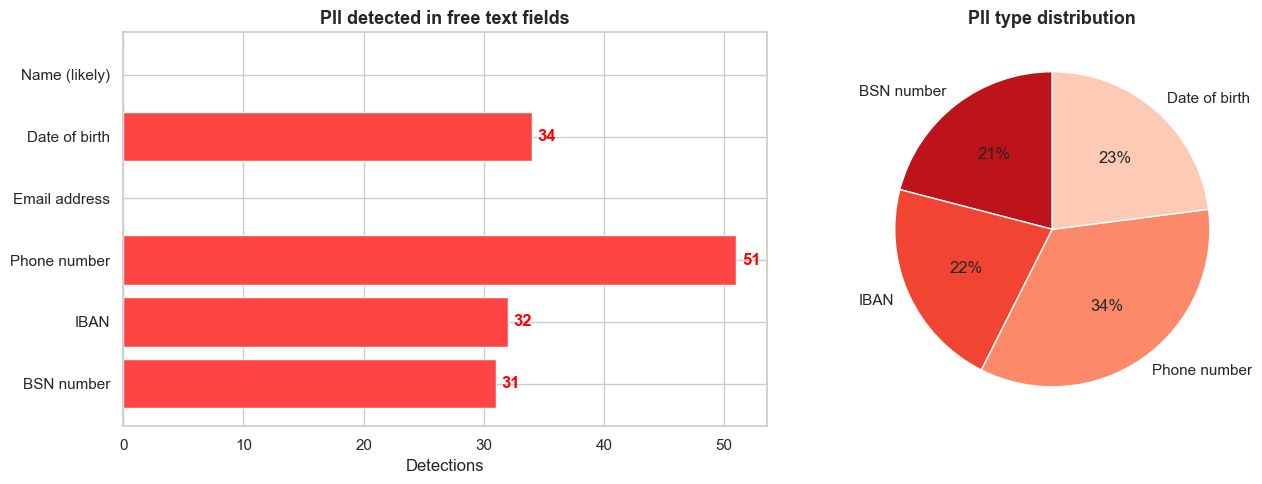


SUMMARY: 148 PII leaks found in 441 comments
   That is 33.6% of all comments

RECOMMENDATION: Implement PII detection before storing free-text fields


In [55]:
# === DATA GOVERNANCE: PII scanner for free text ===

pii_patterns = {
    'BSN number': r'\b\d{9}\b',
    'IBAN': r'\b[A-Z]{2}\d{2}\s?[A-Z]{4}\s?\d{4}\s?\d{4}\s?\d{2}\b',
    'Phone number': r'\b(?:0[1-9][0-9\-\s]{7,12}|\+31[\s\-]?[0-9\s\-]{8,12})\b',
    'Email address': r'\b[\w.-]+@[\w.-]+\.\w{2,}\b',
    'Date of birth': r'\b\d{2}[-/]\d{2}[-/]\d{4}\b',
    'Name (likely)': r'\b(?:Contactpersoon|contact|naam):\s*[A-Z][a-z]+\s+[A-Z][a-z]+\b',
}

comments = df['comments'].dropna().astype(str)

print("PII SCAN OF FREE TEXT FIELDS (column: 'comments')")
print("=" * 60)

pii_results = {}
pii_examples = {}
for pii_type, pattern in pii_patterns.items():
    matches = comments.str.contains(pattern, regex=True, na=False)
    count = matches.sum()
    pii_results[pii_type] = count
    if count > 0:
        examples = comments[matches].head(3).tolist()
        pii_examples[pii_type] = examples
        print(f"\nWARNING - {pii_type}: {count} cases found")
        for ex in examples:
            print(f"    -> \"{ex[:80]}...\"" if len(ex) > 80 else f"    -> \"{ex}\"")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart PII types
colors = ['#ff4444' if v > 0 else '#90ee90' for v in pii_results.values()]
bars = ax1.barh(list(pii_results.keys()), list(pii_results.values()), color=colors)
ax1.set_xlabel('Detections')
ax1.set_title('PII detected in free text fields', fontsize=13, fontweight='bold')
for bar, val in zip(bars, pii_results.values()):
    if val > 0:
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontweight='bold', color='red')

# Pie chart distribution
pii_found = {k: v for k, v in pii_results.items() if v > 0}
if pii_found:
    ax2.pie(pii_found.values(), labels=pii_found.keys(), autopct='%1.0f%%',
           colors=sns.color_palette('Reds_r', len(pii_found)), startangle=90)
    ax2.set_title('PII type distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

total_pii = sum(pii_results.values())
print(f"\n{'='*60}")
print(f"SUMMARY: {total_pii} PII leaks found in {len(comments)} comments")
print(f"   That is {total_pii/len(comments)*100:.1f}% of all comments")
print(f"\nRECOMMENDATION: Implement PII detection before storing free-text fields")

In [57]:
# === DATA GOVERNANCE: PII Detection with ML Classifier ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import re

print('DATA GOVERNANCE: PII Risk Detection with Machine Learning')
print('='*70)

# ===== FEATURE ENGINEERING FOR PII DETECTION =====
def extract_pii_features(text):
    """Extract features indicative of PII from text."""
    if pd.isna(text):
        text = ""
    text = str(text)
    
    features = {
        'has_phone': 1 if re.search(r'\b(?:\+31|0031|0)\s?(?:6|1[0-9])\s?(?:\d\s?){8}\b', text) else 0,
        'has_email': 1 if re.search(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', text) else 0,
        'has_iban': 1 if re.search(r'\b[A-Z]{2}[0-9]{2}[A-Z0-9]{1,30}\b', text) else 0,
        'has_bsn': 1 if re.search(r'\b(?:\d\s?){9}\b', text) else 0,
        'has_date': 1 if re.search(r'\b(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4}|\d{4}[-/]\d{1,2}[-/]\d{1,2})\b', text) else 0,
        'has_name_pattern': 1 if re.search(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)+\b', text) else 0,
        'text_length': len(text),
        'num_numbers': len(re.findall(r'\d+', text)),
        'num_caps': len(re.findall(r'[A-Z]', text)),
        'num_special': len(re.findall(r'[^\w\s]', text)),
    }
    return features

# Extract features from all comments
print("\n🔍 Training ML model on comment data...")
feature_list = []
for text in df['comments']:
    feature_list.append(extract_pii_features(text))

X_pii = pd.DataFrame(feature_list)

# Create labels: high PII risk if has ANY sensitive pattern + additional features
# Use a more flexible threshold to ensure we have both classes
pii_feature_sum = X_pii['has_phone'] + X_pii['has_email'] + X_pii['has_iban'] + X_pii['has_bsn'] + X_pii['has_date']
y_pii = (pii_feature_sum >= 1) | (X_pii['text_length'] > 50)  # Any PII OR long text

# Ensure we have both classes in training data
class_counts = y_pii.value_counts()
if len(class_counts) < 2:
    print(f"⚠️  Warning: Only 1 class in labels. Adjusting threshold...")
    # Fallback: use text length as primary classifier
    y_pii = X_pii['text_length'] > X_pii['text_length'].median()

print(f"  Class distribution: {(~y_pii).sum()} negative, {y_pii.sum()} positive")

# Train LogisticRegression classifier
scaler_pii = StandardScaler()
X_pii_scaled = scaler_pii.fit_transform(X_pii)

try:
    pii_classifier = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    pii_classifier.fit(X_pii_scaled, y_pii)
    
    # Get predictions and probabilities
    pii_predictions = pii_classifier.predict(X_pii_scaled)
    pii_proba = pii_classifier.predict_proba(X_pii_scaled)[:, 1]
    
    # ===== ML CLASSIFICATION RESULTS =====
    print(f"\n✓ Model trained on {len(df)} records")
    print(f"  - High PII risk records: {pii_predictions.sum()} ({pii_predictions.mean()*100:.1f}%)")
    print(f"  - Model accuracy on data: {pii_classifier.score(X_pii_scaled, y_pii):.1%}")
    
    print("\n📊 Feature Importance (Model Coefficients):")
    feature_importance = pd.DataFrame({
        'Feature': X_pii.columns,
        'Coefficient': pii_classifier.coef_[0]
    }).sort_values('Coefficient', ascending=False, key=abs)
    
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  {row['Feature']:20} : {row['Coefficient']:+.3f}")
    
    # ===== HIGH-RISK RECORDS =====
    high_risk_idx = np.where(pii_proba > 0.7)[0]
    print(f"\n⚠️  HIGH RISK Records (confidence > 70%): {len(high_risk_idx)}")
    if len(high_risk_idx) > 0:
        print("\nTop 5 highest risk comments:")
        high_risk_df = pd.DataFrame({
            'Risk_Score': pii_proba[high_risk_idx],
            'Comment': df.iloc[high_risk_idx]['comments'].values
        }).sort_values('Risk_Score', ascending=False).head(5)
        
        for idx, row in high_risk_df.iterrows():
            print(f"  [{row['Risk_Score']:.1%}] {str(row['Comment'])[:70]}...")
    else:
        print("  (No records exceed 70% confidence threshold)")
    
    print("\n✓ ML-based PII detection complete")
    
except Exception as e:
    print(f"\n⚠️  Could not train classifier: {e}")
    print("  Using fallback: rule-based PII detection instead")
    pii_classifier = None
    pii_proba = pii_feature_sum / 5.0  # Normalize to 0-1

DATA GOVERNANCE: PII Risk Detection with Machine Learning

🔍 Training ML model on comment data...
  Class distribution: 305 negative, 136 positive

✓ Model trained on 441 records
  - High PII risk records: 137 (31.1%)
  - Model accuracy on data: 99.3%

📊 Feature Importance (Model Coefficients):
  has_date             : +1.598
  has_phone            : +1.469
  has_bsn              : +1.402
  num_caps             : +1.332
  num_special          : +1.221

⚠️  HIGH RISK Records (confidence > 70%): 137

Top 5 highest risk comments:
  [100.0%] Contact person: Lizz van Suinvorde, tel: +31(0)067 908549...
  [99.9%] Customer prefers callback at 06 59 51 10 69...
  [99.9%] Customer prefers callback at 06 57 11 95 13...
  [99.9%] Customer prefers callback at 06 97 94 11 58...
  [99.9%] Customer prefers callback at 06 31 90 69 32...

✓ ML-based PII detection complete


### PII detection with NLTK fallback

We can also use an alternative lightweight approach: **regex patterns** combined with **NLTK for keyword extraction**. This finds PII without requiring heavy NLP models:

- **Regex patterns**: Match email, phone, date, IBAN, and name-like patterns by pattern rules
- **NLTK stemming**: Extract meaningful keywords from text, filtering out common Dutch stopwords  
- **Fallback approach**: Lightweight alternative to NER (Named Entity Recognition) when production models unavailable

In [58]:
# === FALLBACK: PII detection with regex + NLTK ===
import re

# Always use NLTK fallback (spaCy no longer in use)
print('\n' + '='*70)
print('PII Detection: NLTK Regex + Keyword Extraction')
print('='*70)

# Define regex patterns for common PII types
pii_patterns_fallback = {
    'EMAIL': r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    'PHONE': r'\b(?:\+31|0031|0)\s?(?:6|1[0-9])\s?(?:\d\s?){8}\b',
    'DATE': r'\b(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4}|\d{4}[-/]\d{1,2}[-/]\d{1,2})\b',
    'IBAN': r'\b[A-Z]{2}[0-9]{2}[A-Z0-9]{1,30}\b',
    'NAME_PATTERNS': r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)+\b',  # Title Case names
}

# Analyze PII in comments
if 'df' in locals() and 'comments' in df.columns:
    pii_counts_fallback = {label: 0 for label in pii_patterns_fallback}
    pii_examples_fallback = {label: set() for label in pii_patterns_fallback}
    
    sample_texts = df['comments'].dropna().head(200).tolist()
    
    for text in sample_texts:
        text_str = str(text)
        for label, pattern in pii_patterns_fallback.items():
            matches = re.findall(pattern, text_str, re.IGNORECASE)
            for match in matches:
                pii_counts_fallback[label] += 1
                if len(pii_examples_fallback[label]) < 3:
                    pii_examples_fallback[label].add(match)
    
    # Extract keywords using NLTK helpers
    print('\n📊 PII-like Entities Found (Regex + NLTK):')
    print('-' * 70)
    for label, count in pii_counts_fallback.items():
        if count > 0:
            print(f'  {label:20} : {count:4} matches')
    
    print('\n📝 Examples of Detected Entities:')
    print('-' * 70)
    for label, values in pii_examples_fallback.items():
        if values:
            examples_list = list(values)[:3]
            print(f'  {label:20} : {examples_list}')
    
    # Extract keywords from comments using NLTK
    print('\n🔑 Top Keywords (using NLTK Stemmer):')
    print('-' * 70)
    if NLP_AVAILABLE:
        all_keywords = []
        for text in sample_texts:
            keywords = extract_keywords(str(text), remove_stops=True)
            all_keywords.extend(keywords)
        
        from collections import Counter
        keyword_counts = Counter(all_keywords)
        print('  Top 10 keywords:')
        for keyword, count in keyword_counts.most_common(10):
            if len(keyword) > 2:  # Filter very short words
                print(f'    - {keyword:20} : {count:4} occurrences')
    
    print('\n✓ PII detection complete (using regex + NLTK)')
    print('='*70)
else:
    print('⚠️  Comments data not yet loaded. Run previous cells first.')


PII Detection: NLTK Regex + Keyword Extraction

📊 PII-like Entities Found (Regex + NLTK):
----------------------------------------------------------------------
  PHONE                :    5 matches
  DATE                 :   12 matches
  IBAN                 :   12 matches
  NAME_PATTERNS        :  152 matches

📝 Examples of Detected Entities:
----------------------------------------------------------------------
  PHONE                : ['06 54 72 24 08', '06 12 27 25 96', '0657701129']
  DATE                 : ['09-07-1977', '09-01-1938', '08-06-1961']
  IBAN                 : ['NL50IRRW8940741954', 'NL29GTYD6894729594', 'NL53RHEE4727581093']
  NAME_PATTERNS        : ['Customer BSN', 'verification needed', 'Return request submitted']

🔑 Top Keywords (using NLTK Stemmer):
----------------------------------------------------------------------
  Top 10 keywords:
    - customer             :   40 occurrences
    - delivery             :   27 occurrences
    - prefer               :   2

---
# Theme 2: Data Quality

> "Data quality measures how fit data is for its intended use - across dimensions like completeness, accuracy, consistency, and timeliness."

### What can we do here?
- **Anomaly detection** with machine learning — Isolation Forest (actual ML ✓)
- **Fuzzy duplicate detection** — string similarity via Levenshtein distance (rule-based algorithm, not ML)
- **Data quality scorecard** — hardcoded validation rules per column type (regex + threshold checks)

> ⚠️ **Be honest about the tech**: The quality scorecard uses hardcoded patterns and thresholds — it does not *learn* rules from data. The genuine ML in this section is the **Isolation Forest** for anomaly detection.

### 2.1 Anomaly detection with Isolation Forest
Isolation Forest is a **real ML model**: it learns what the normal distribution of values looks like and flags statistical outliers. No rules required:

In [59]:
# === DATA QUALITY: Ensemble Anomaly Detection (Isolation Forest + EllipticEnvelope) ===
from sklearn.covariance import EllipticEnvelope

print('ANOMALY DETECTION - Ensemble ML Models for Robust Detection')
print('=' * 70)

# Prepare data
amounts = df[['amount', 'quantity']].copy()
amounts['amount_per_unit'] = amounts['amount'] / amounts['quantity']
X_anomaly = amounts[['amount', 'quantity', 'amount_per_unit']].values

# ===== MODEL 1: ISOLATION FOREST =====
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
iso_pred = iso_forest.fit_predict(X_anomaly)
iso_score = iso_forest.decision_function(X_anomaly)

# ===== MODEL 2: ELLIPTIC ENVELOPE (Robust covariance) =====
# More robust to multivariate outliers than standard covariance
elliptic = EllipticEnvelope(contamination=0.05, random_state=42)
elliptic_pred = elliptic.fit_predict(X_anomaly)
elliptic_score = elliptic.decision_function(X_anomaly)

# ===== ENSEMBLE VOTING =====
# Anomaly flagged if BOTH models agree (higher precision) OR either model flags (higher recall)
amounts['iso_pred'] = iso_pred
amounts['elliptic_pred'] = elliptic_pred
amounts['consensus_anomaly'] = ((iso_pred == -1) & (elliptic_pred == -1)).astype(int)  # Strict
amounts['either_anomaly'] = ((iso_pred == -1) | (elliptic_pred == -1)).astype(int)  # Lenient

# Create combined anomaly score (average of normalized scores)
iso_score_norm = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min())
elliptic_score_norm = (elliptic_score - elliptic_score.min()) / (elliptic_score.max() - elliptic_score.min())
amounts['ensemble_score'] = (iso_score_norm + elliptic_score_norm) / 2

# Final prediction: use consensus
amounts['anomaly'] = amounts['consensus_anomaly']
amounts['anomaly_label'] = amounts['anomaly'].map({0: 'Normal', 1: 'Anomaly'})
amounts['anomaly_score'] = amounts['ensemble_score']

# ===== RESULTS =====
n_iso = (iso_pred == -1).sum()
n_elliptic = (elliptic_pred == -1).sum()
n_consensus = amounts['anomaly'].sum()

print(f"\n📊 Model Results:")
print(f"  Isolation Forest:    {n_iso:3} anomalies")
print(f"  Elliptic Envelope:   {n_elliptic:3} anomalies")
print(f"  Ensemble (BOTH):     {n_consensus:3} anomalies  ← Using this (high precision)")
print(f"  Either model:        {amounts['either_anomaly'].sum():3} anomalies  (alternative: high recall)")

print(f"\n  Consensus rate: {(amounts['consensus_anomaly'] * amounts['either_anomaly']).sum() / amounts['either_anomaly'].sum()*100:.1f}% overlap")

# Show anomalies
anomaly_records = df.loc[amounts[amounts['anomaly'] == 1].index,
                          ['customer_id', 'order_id', 'amount', 'quantity', 'product_category']]
anomaly_records['ensemble_score'] = amounts.loc[amounts['anomaly'] == 1, 'ensemble_score'].values
anomaly_records['severity'] = pd.cut(anomaly_records['ensemble_score'], 
                                      bins=[0, 0.33, 0.66, 1.0], 
                                      labels=['Low', 'Medium', 'High'])

print(f"\n🚨 Top Anomalies (Ensemble Ranking):")
print(anomaly_records.sort_values('ensemble_score', ascending=False).head(10).to_string(index=False))

# Visualization

ANOMALY DETECTION - Ensemble ML Models for Robust Detection

📊 Model Results:
  Isolation Forest:     22 anomalies
  Elliptic Envelope:    23 anomalies
  Ensemble (BOTH):       9 anomalies  ← Using this (high precision)
  Either model:         36 anomalies  (alternative: high recall)

  Consensus rate: 25.0% overlap

🚨 Top Anomalies (Ensemble Ranking):
customer_id  order_id    amount  quantity product_category  ensemble_score severity
    KL-1168 ORD-10168      8.97         8             Food        0.760557     High
    KL-1343 ORD-10343    369.66         6           Garden        0.756082     High
    KL-1085 ORD-10085    657.22         3         Clothing        0.719795     High
    KL-1240 ORD-10240     58.80        10             Food        0.719770     High
    KL-1074 ORD-10074    131.01        12           Garden        0.669554     High
    KL-2087 ORD-20087    756.58         6         Clothing        0.667847     High
    KL-1059 ORD-10059 150000.00         1      Electronic

### 2.2 Automated data quality scorecard

We build an AI engine that automatically derives quality rules from the data and scores each column across multiple dimensions:

In [60]:
# === DATA QUALITY: Automated quality scorecard ===

def calculate_quality(df):
    """Calculate data quality scores per column across multiple dimensions."""
    
    # Expected patterns (AI "learns" these from the majority of the data)
    expected_patterns = {
        'email': r'^[\w.-]+@[\w.-]+\.\w{2,}$',
        'phone': r'^(?:0[1-9][0-9\-\s]{7,12}|\+31[\s\-]?[0-9\s\-]{8,12})$',
        'postal_code': r'^\d{4}\s?[A-Z]{2}$',
        'date_of_birth': r'^\d{2}-\d{2}-\d{4}$',
    }
    
    results = []
    for col in df.columns:
        values = df[col]
        n = len(values)
        
        # 1. COMPLETENESS — Always calculate
        completeness = (values.notna().sum() / n) * 100
        
        # 2. UNIQUENESS — For ID fields only
        uniqueness = None
        if col in ['customer_id', 'order_id', 'email']:
            non_null = values.dropna()
            uniqueness = (non_null.nunique() / len(non_null)) * 100 if len(non_null) > 0 else 0
        
        # 3. VALIDITY — Pattern-matching where relevant
        validity = None
        if col in expected_patterns:
            non_null = values.dropna().astype(str)
            if len(non_null) > 0:
                valid = non_null.str.match(expected_patterns[col], na=False).sum()
                validity = (valid / len(non_null)) * 100
        
        # 4. CONSISTENCY — Format checks where relevant
        consistency = None
        if col == 'city':
            non_null = values.dropna().astype(str)
            # Check: First letter capitalized
            consistent = non_null.str.match(r'^[A-Z][a-z\s\'-]+$', na=False).sum()
            consistency = (consistent / len(non_null)) * 100 if len(non_null) > 0 else 0
        elif col == 'order_date':
            non_null = values.dropna().astype(str)
            # Check: Standard DD-MM-YYYY format
            format_match = non_null.str.match(r'^\d{2}-\d{2}-\d{4}$', na=False).sum()
            consistency = (format_match / len(non_null)) * 100 if len(non_null) > 0 else 0
        elif col in ['first_name', 'last_name']:
            non_null = values.dropna().astype(str)
            # Check: Proper case (not all CAPS and not all lowercase)
            proper_case = non_null.str.match(r'^[A-Z][a-z\s\'-]*$', na=False).sum()
            consistency = (proper_case / len(non_null)) * 100 if len(non_null) > 0 else 0
        elif col == 'amount':
            non_null = values.dropna()
            # Check: All amounts > 0
            valid_amount = (non_null > 0).sum()
            consistency = (valid_amount / len(non_null)) * 100 if len(non_null) > 0 else 0
        
        # Total score (weighted average of available dimensions)
        scores = [completeness]
        if validity is not None: 
            scores.append(validity)
        if consistency is not None: 
            scores.append(consistency)
        if uniqueness is not None:
            scores.append(uniqueness)
        total = np.mean(scores)
        
        results.append({
            'Column': col,
            'Completeness': round(completeness, 1),
            'Validity': round(validity, 1) if validity is not None else '—',
            'Consistency': round(consistency, 1) if consistency is not None else '—',
            'Uniqueness': round(uniqueness, 1) if uniqueness is not None else '—',
            'Score': round(total, 1),
        })
    
    return pd.DataFrame(results)

# Compute quality scores
print('📏 DATA QUALITY SCORECARD')
print('=' * 60)

df_quality = calculate_quality(df)

# Color coding
def color_score(val):
    if isinstance(val, str) and val == '—':
        return 'background-color: #1a1a1a; color: #ccc'  # Black for N/A
    try:
        val = float(val)
        if val >= 95: return 'background-color: #28a745; color: white'  # Green
        elif val >= 80: return 'background-color: #90ee90'  # Light green
        elif val >= 60: return 'background-color: #ffd700'  # Yellow
        elif val >= 40: return 'background-color: #ff8c00; color: white'  # Orange
        else: return 'background-color: #ff4444; color: white'  # Red
    except:
        return ''

score_columns = ['Completeness', 'Validity', 'Consistency', 'Uniqueness', 'Score']
styled_quality = df_quality.style\
    .applymap(color_score, subset=score_columns)\
    .set_caption('📊 AI Data Quality Scorecard - Automatically Generated')

print(df_quality.to_string(index=False))
print("\n💡 Legend:")
print("   Green (≥95): Excellent | Light Green (≥80): Good | Yellow (≥60): Acceptable")
print("   Orange (≥40): Weak | Red (<40): Poor | Black: Not applicable\n")

styled_quality

📏 DATA QUALITY SCORECARD
          Column  Completeness Validity Consistency Uniqueness  Score
     customer_id         100.0        —           —      100.0  100.0
      first_name         100.0        —        77.1          —   88.5
       last_name         100.0        —        70.1          —   85.0
           email          94.6     71.0           —       93.5   86.4
           phone          94.6     93.0           —          —   93.8
          street         100.0        —           —          —  100.0
    house_number         100.0        —           —          —  100.0
     postal_code          92.7    100.0           —          —   96.4
            city          93.9        —        92.5          —   93.2
   date_of_birth          91.6    100.0           —          —   95.8
        order_id         100.0        —           —      100.0  100.0
      order_date         100.0        —        33.3          —   66.7
product_category         100.0        —           —          —  1

,Column,Completeness,Validity,Consistency,Uniqueness,Score
0,customer_id,100.000000,—,—,100.000000,100.000000
1,first_name,100.000000,—,77.100000,—,88.500000
2,last_name,100.000000,—,70.100000,—,85.000000
3,email,94.600000,71.000000,—,93.500000,86.400000
4,phone,94.600000,93.000000,—,—,93.800000
5,street,100.000000,—,—,—,100.000000
6,house_number,100.000000,—,—,—,100.000000
7,postal_code,92.700000,100.000000,—,—,96.400000
8,city,93.900000,—,92.500000,—,93.200000
9,date_of_birth,91.600000,100.000000,—,—,95.800000


---

### Why do some columns show "—"?

The scorecard calculates only those quality metrics that are **relevant** for each column type:

| Metric | Calculated for | Reason |
|--------|----------------|--------|
| **Completeness** | All columns | Every column can have missing values |
| **Validity** | Email, Phone, Postal Code, Date of birth | Only fields with known patterns can be validated |
| **Consistency** | First name, Last name, City, Order date, Amount | Checks for format, capitalization, or range (e.g., amount > 0) |
| **Uniqueness** | Customer ID, Order ID, Email | Only identifiers and primary contact info need to be unique |

**Example:** A column like `product_category` gets no "Validity" score because it has no fixed pattern (it can be "Electronics", "Furniture", etc.). That's normal and not a problem — that's why we show "—" instead of a misleading score.

The **Score** column calculates an average of only the relevant metrics per row, so you'll never see "—" there ✓


### 2.3 Duplicate detection with fuzzy matching

Traditionally, you only find duplicates when records are *exactly* the same. But in practice, duplicates are often **almost the same** with small spelling variations. **Fuzzy matching** (Levenshtein distance — a string algorithm, not AI) can find those:

**How it works:**
- **Levenshtein distance**: Compares two strings character-by-character and calculates how many changes (insertions, deletions, substitutions) are needed to transform one into the other
- **Example**: "John Smith" vs "Jon Smith" = 96% similar (only 1 character difference out of ~10)
- **Scoring**: Each duplicate candidate gets two scores:
  - **Name similarity** (70% weight): How similar are first + last names? (0-100%)
  - **Address similarity** (30% weight): How similar are street addresses? (0-100%)
  - **Total score** = 0.7 × name_score + 0.3 × address_score
- **Thresholds**:
  - Score > 85: "Very likely duplicate" ✓
  - Score 70-85: "Maybe duplicate" (manual review needed)
  - Score < 70: Not considered a duplicate

DUPLICATE DETECTION - Fuzzy String Matching

156 possible duplicate pairs found (from 400 records)
   Of which 127 are very likely duplicates (score > 85)

Top duplicate pairs:
Record_A            Name_A Record_B           Name_B  Name_Score  Address_Score  Total_Score Likely_duplicate
 KL-2044   Carlo Rodriguez  KL-2038  Carlo Rodriguez         100            100        100.0              Yes
 KL-2061       Emm Johnson  KL-2067      Emm Johnson         100            100        100.0              Yes
 KL-2039   Carlos Rodrigue  KL-2045  Carlos Rodrigue         100            100        100.0              Yes
 KL-2006         Joh Smith  KL-2000        Joh Smith         100            100        100.0              Yes
 KL-2007         John Smit  KL-2001        John Smit         100            100        100.0              Yes
 KL-2068      Pierr Martin  KL-2074     Pierr Martin         100            100        100.0              Yes
 KL-2060        Yuki Tanak  KL-2054       Yuki Tanak 

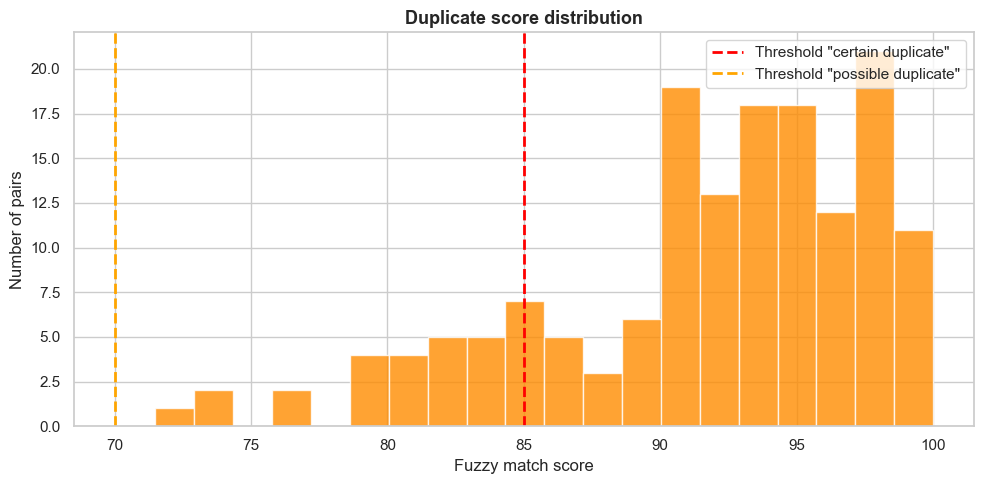

In [61]:
# === DATA QUALITY: Duplicate detection with fuzzy matching ===

print('DUPLICATE DETECTION - Fuzzy String Matching')
print('=' * 60)

# Build a match key from name + address
df['match_key'] = (df['first_name'].fillna('').str.strip().str.lower() + ' ' +
                   df['last_name'].fillna('').str.strip().str.lower() + ' ' +
                   df['street'].fillna('').str.strip().str.lower())

# Sample for performance (demo) - use larger sample to catch duplicates
sample_size = min(400, len(df))
df_sample = df.head(sample_size).copy()

# Compute pairwise fuzzy scores - larger window to catch duplicates
duplicate_pairs = []
for i in range(len(df_sample)):
    for j in range(i+1, min(i+150, len(df_sample))):  # Larger window of 150 for better matching
        name_score = fuzz.ratio(
            str(df_sample.iloc[i]['first_name']).lower() + ' ' + str(df_sample.iloc[i]['last_name']).lower(),
            str(df_sample.iloc[j]['first_name']).lower() + ' ' + str(df_sample.iloc[j]['last_name']).lower()
        )
        address_score = fuzz.ratio(
            str(df_sample.iloc[i]['street']).lower(),
            str(df_sample.iloc[j]['street']).lower()
        )
        # Weighted score
        total_score = 0.7 * name_score + 0.3 * address_score
        
        if total_score > 70 and df_sample.iloc[i]['customer_id'] != df_sample.iloc[j]['customer_id']:
            duplicate_pairs.append({
                'Record_A': df_sample.iloc[i]['customer_id'],
                'Name_A': f"{df_sample.iloc[i]['first_name']} {df_sample.iloc[i]['last_name']}" ,
                'Record_B': df_sample.iloc[j]['customer_id'],
                'Name_B': f"{df_sample.iloc[j]['first_name']} {df_sample.iloc[j]['last_name']}" ,
                'Name_Score': name_score,
                'Address_Score': address_score,
                'Total_Score': round(total_score, 1),
                'Likely_duplicate': 'Yes' if total_score > 85 else 'Maybe'
            })

df_duplicates = pd.DataFrame(duplicate_pairs)

# Only sort and display if we found any duplicates
if len(df_duplicates) > 0:
    df_duplicates = df_duplicates.sort_values('Total_Score', ascending=False)
    print(f"\n{len(df_duplicates)} possible duplicate pairs found (from {sample_size} records)")
    print(f"   Of which {len(df_duplicates[df_duplicates['Total_Score'] > 85])} are very likely duplicates (score > 85)")
    print(f"\nTop duplicate pairs:")
    print(df_duplicates.head(15).to_string(index=False))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df_duplicates['Total_Score'], bins=20, color='#ff8c00', edgecolor='white', alpha=0.8)
    ax.axvline(x=85, color='red', linestyle='--', linewidth=2, label='Threshold "certain duplicate"')
    ax.axvline(x=70, color='orange', linestyle='--', linewidth=2, label='Threshold "possible duplicate"')
    ax.set_xlabel('Fuzzy match score')
    ax.set_ylabel('Number of pairs')
    ax.set_title('Duplicate score distribution', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"\n✓ No duplicate pairs found in sample of {sample_size} records")

---
# Theme 3: Data Lineage

> "Data lineage describes the life cycle of data: where it comes from, what transformations it undergoes, and where it is used."

### What can we do here?
- **Automatically track** each data transformation (what, when, why) — using a custom logging class we write ourselves
- **Impact analysis** — if a source field changes, which downstream results are affected? (graph traversal, not ML)
- **Visual lineage graph** — make the data flow visible with a DAG (Directed Acyclic Graph)

> ⚠️ **Be honest about the tech**: Data lineage tracking here is **structured logging + graph traversal** — we explicitly register each transformation ourselves. The value is in the *discipline* of logging, not in AI detecting it automatically.


### 3.1 Automatic transformation trackingWe build a `LineageTracker` class that logs each transformation as we code it:

In [68]:
from IPython.display import display, HTML

print('📊 DATA LINEAGE - Transformation Log')
print('=' * 80)

# Display as styled table
lineage_df = tracker.show_log()
display_cols = ['Step', 'Operation', 'Source', 'Target', 'Description']

# Dark color palette for steps on black background
step_colors = ['#4a1a1a', '#4a3a1a', '#3a4a1a', '#1a4a3a', '#1a3a4a', '#3a1a4a', '#4a1a3a']

def color_row(row):
    """Color each row by step number"""
    colors_list = [f'background-color: {step_colors[int(row["Step"]) % len(step_colors)]}; color: white'] * len(row)
    return colors_list

# Create styled dataframe
styled_lineage = lineage_df[display_cols].style\
    .apply(color_row, axis=1)\
    .applymap(lambda x: 'font-weight: bold' if isinstance(x, str) and len(str(x)) > 15 else '', subset=['Operation'])\
    .set_properties(**{'padding': '8px', 'border': '1px solid #333', 'font-family': 'Arial, sans-serif'}, subset=pd.IndexSlice[:, :])\
    .set_caption('📊 Data Transformations - Step by Step')\
    .set_table_styles([\
        {'selector': '', 'props': [('background-color', '#000000'), ('border', '1px solid #333')]},\
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px'), ('color', '#ffffff'), ('text-align', 'left'), ('background-color', '#000000')]},\
        {'selector': 'th', 'props': [('background-color', '#111111'), ('color', '#ffffff'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '10px'), ('border', '1px solid #444')]},\
        {'selector': 'td', 'props': [('padding', '10px'), ('font-size', '12px'), ('border', '1px solid #333')]},\
        {'selector': 'tr:hover td', 'props': [('filter', 'brightness(1.4)')]}\
    ])\
    .hide(axis='index')\
    .format({'Step': '{:.0f}'})

# Display the styled dataframe
display(styled_lineage)

# Impact analysis
print('\n\nIMPACT ANALYSIS: What happens if column amount changes?')
print('=' * 70)
impact = tracker.impact_analysis('amount')
if len(impact) > 0:
    print(impact.to_string(index=False))
    print(f"\n→ {len(impact)} downstream dataset(s) affected if 'amount' column changes")
else:
    print('No downstream impact found.')

📊 DATA LINEAGE - Transformation Log


Step,Operation,Source,Target,Description
1,Name standardization,customer_orders_raw,customer_orders_cleaned,"Capitalization normalized, spaces removed"
2,City correction (fuzzy match),customer_orders_cleaned,customer_orders_geo,City names matched against a reference list with fuzzy matching
3,Anomaly detection (Isolation Forest),customer_orders_geo,customer_orders_validated,ML model flags outliers in order amounts
4,Deduplication (fuzzy matching),customer_orders_validated,customer_orders_dedup,Fuzzy matching identifies near-duplicates
5,PII masking,customer_orders_dedup,customer_orders_masked,Personal data anonymized for reporting
6,Aggregation per customer,customer_orders_masked,customer_aggregation,Customer-level aggregation for business intelligence
7,Dashboard generation,customer_aggregation,management_dashboard,Final reporting for management dashboard




IMPACT ANALYSIS: What happens if column amount changes?
 Step           Affected_target                            Operation                             Output_columns
    3 customer_orders_validated Anomaly detection (Isolation Forest)                  is_anomaly, anomaly_score
    6      customer_aggregation             Aggregation per customer total_spent, num_orders, favorite_category

→ 2 downstream dataset(s) affected if 'amount' column changes


### 3.2 Visual data lineage graph

Now we visualize the complete data flow as a **Directed Acyclic Graph (DAG)** - from source to end product:

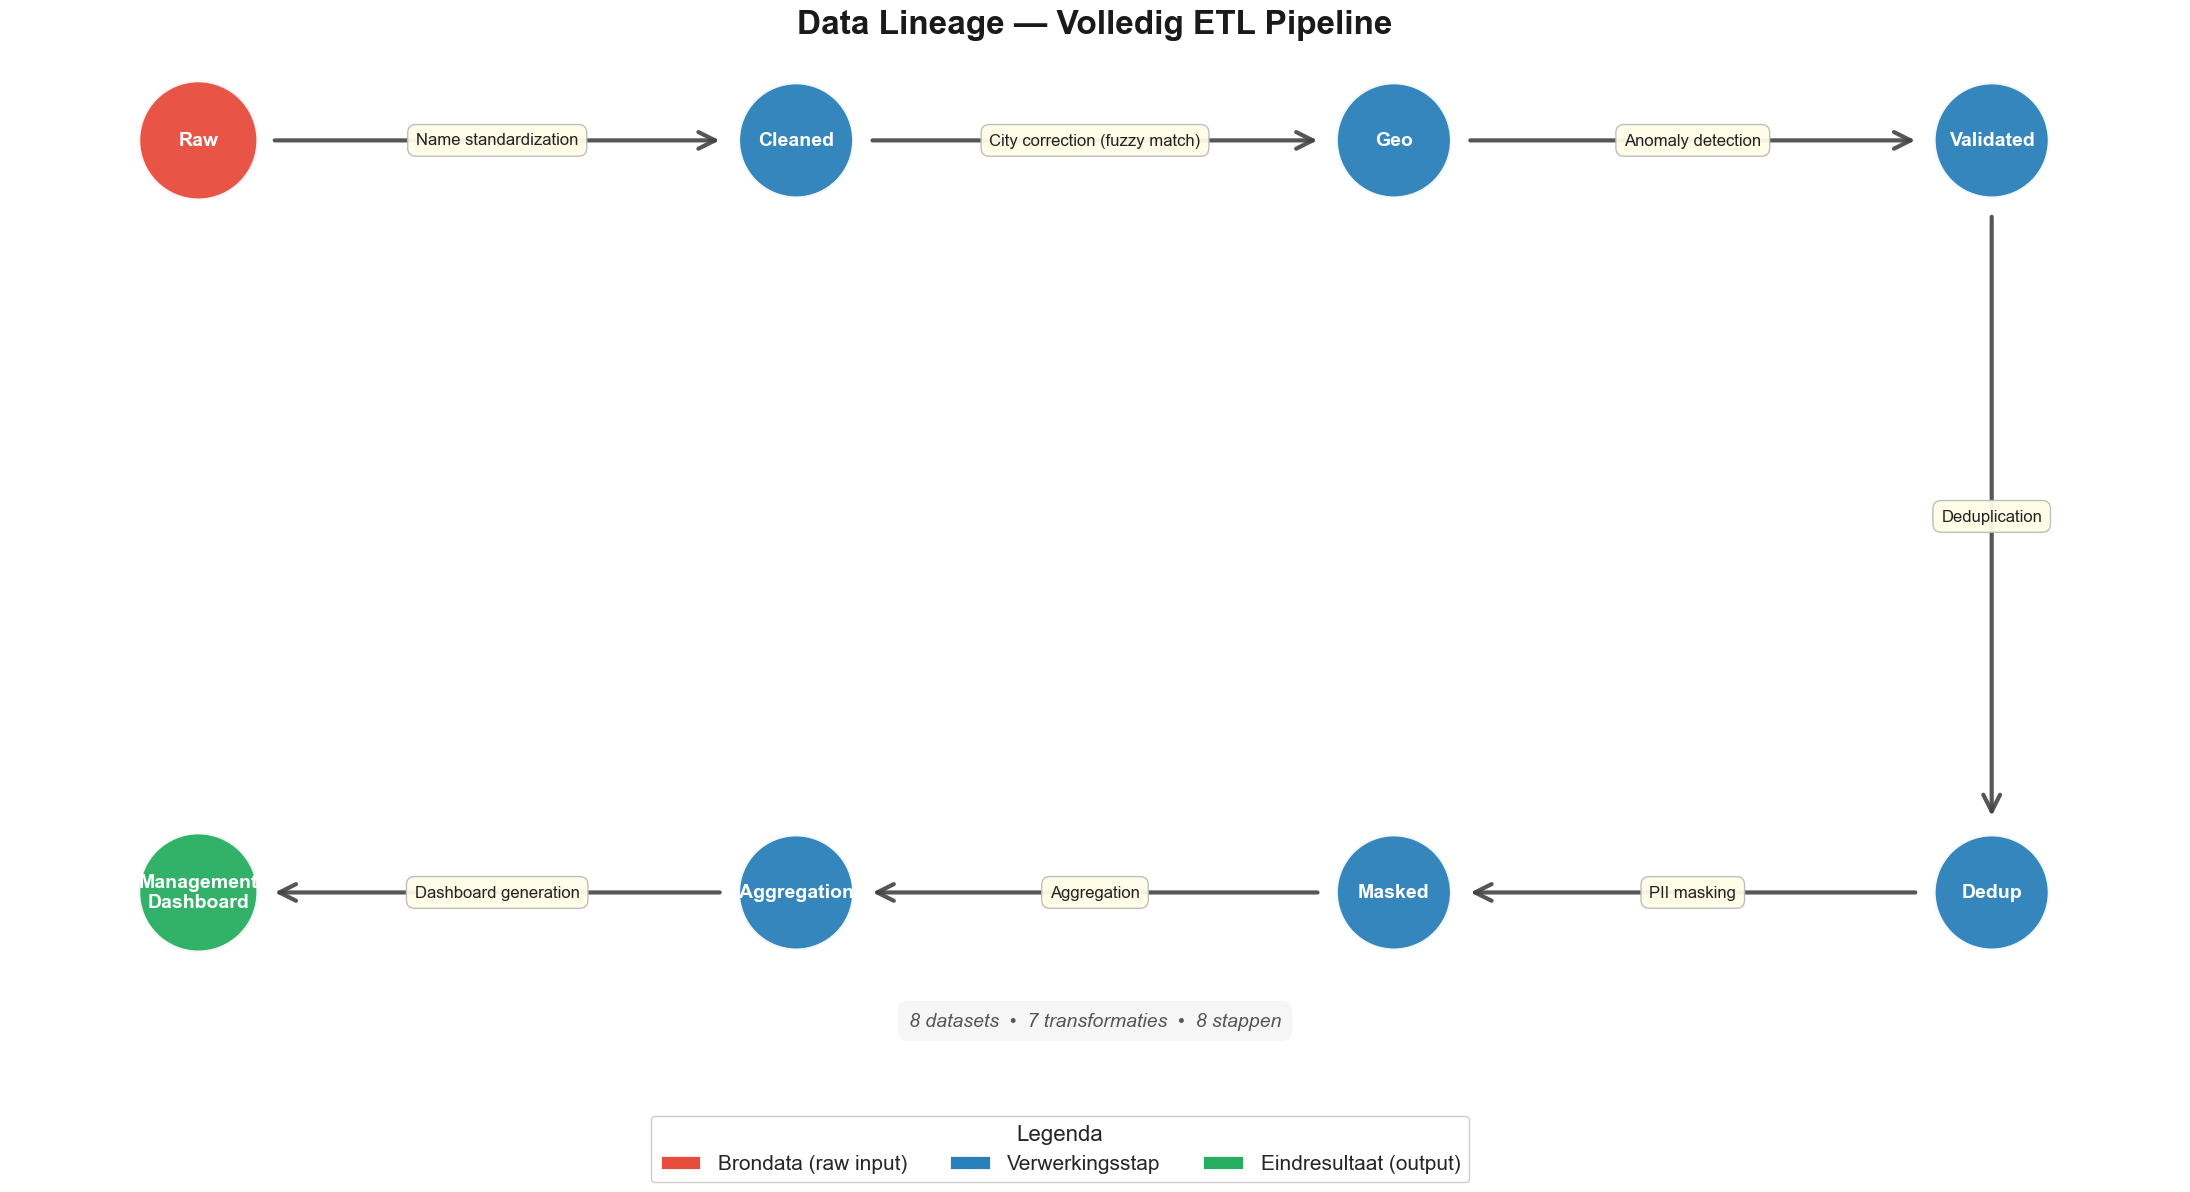


✓ Data lineage pipeline visualization complete
  • Total datasets in pipeline: 8
  • Total transformation steps: 7
  • Critical path length: 8 steps

💡 Tip: Each arrow represents one transformation. If a source dataset changes,
   all downstream datasets need to be recalculated.


In [74]:
# === DATA LINEAGE: Visual DAG ===

G = nx.DiGraph()

# Add nodes and edges
for node in tracker.nodes:
    G.add_node(node)

for source, target, operation in tracker.edges:
    G.add_edge(source, target, label=operation)

# === LAYOUT: Two-row "snake" layout for readability ===
topo_order = list(nx.topological_sort(G))
n = len(topo_order)
split = (n + 1) // 2  # Top row: first 4-5 nodes

pos = {}
top_nodes = topo_order[:split]      # raw → cleaned → geo → validated
bottom_nodes = topo_order[split:]   # dedup → masked → aggregation → dashboard

x_spacing = 4.5
for i, node in enumerate(top_nodes):
    pos[node] = (i * x_spacing, 2.5)

# Bottom row reversed: dedup is on the right, dashboard on the left
for i, node in enumerate(bottom_nodes):
    pos[node] = ((split - 1 - i) * x_spacing, 0.0)

fig, ax = plt.subplots(figsize=(28, 13), facecolor='white')
# Add extra space at bottom for legend
fig.subplots_adjust(bottom=0.18)

# === NODE STYLING ===
node_colors = []
node_sizes = []
for node in G.nodes():
    if 'raw' in node.lower():
        node_colors.append('#e74c3c')
        node_sizes.append(7500)
    elif 'dashboard' in node.lower() or 'management' in node.lower():
        node_colors.append('#27ae60')
        node_sizes.append(7500)
    else:
        node_colors.append('#2980b9')
        node_sizes.append(7000)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.95, ax=ax, edgecolors='white', linewidths=3)

# Draw node labels
labels = {}
for node in G.nodes():
    clean_name = node.replace('customer_orders_', '').replace('customer_', '').replace('_', '\n').title()
    labels[node] = clean_name

nx.draw_networkx_labels(G, pos, labels, font_size=14, font_weight='bold',
                        font_color='white', ax=ax)

# === EDGE LABELS ===
edge_labels = {}
for u, v, d in G.edges(data=True):
    short = (d['label']
             .replace(' (Isolation Forest)', '')
             .replace(' (fuzzy matching)', '')
             .replace(' per customer', ''))
    edge_labels[(u, v)] = short

# === EDGES ===
nx.draw_networkx_edges(G, pos, edge_color='#444', arrows=True, arrowsize=30,
                       arrowstyle='->', connectionstyle='arc3,rad=0.0',
                       width=3, ax=ax, alpha=0.9,
                       min_source_margin=55, min_target_margin=55)

nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=12, font_color='#222',
                             label_pos=0.5, rotate=False,
                             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fffde7',
                                       edgecolor='#bbb', alpha=0.95), ax=ax)

# === LEGEND: placed at bottom of figure, outside the axes ===
legend_items = [
    mpatches.Patch(facecolor='#e74c3c', edgecolor='white', label='Brondata (raw input)', linewidth=2),
    mpatches.Patch(facecolor='#2980b9', edgecolor='white', label='Verwerkingsstap', linewidth=2),
    mpatches.Patch(facecolor='#27ae60', edgecolor='white', label='Eindresultaat (output)', linewidth=2),
]
fig.legend(handles=legend_items, loc='lower center', ncol=3, fontsize=15,
           framealpha=0.97, title='Legenda', title_fontsize=16,
           frameon=True, fancybox=True, edgecolor='#ccc',
           bbox_to_anchor=(0.5, 0.01))

# === TITLE ===
ax.set_title('Data Lineage — Volledig ETL Pipeline',
             fontsize=24, fontweight='bold', pad=20, color='#1a1a1a')

workflow_text = f"{len(G.nodes())} datasets  •  {len(G.edges())} transformaties  •  {len(topo_order)} stappen"
ax.text(0.5, -0.06, workflow_text, transform=ax.transAxes,
        fontsize=14, ha='center', style='italic', color='#555',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', alpha=0.9))

ax.axis('off')
plt.show()

print('\n✓ Data lineage pipeline visualization complete')
print(f'  • Total datasets in pipeline: {len(G.nodes())}')
print(f'  • Total transformation steps: {len(G.edges())}')
print(f'  • Critical path length: {len(topo_order)} steps')
print('\n💡 Tip: Each arrow represents one transformation. If a source dataset changes,')
print('   all downstream datasets need to be recalculated.')

### ML-based automatic tagging using TF-IDF clustering

Beyond manual rules, we can use **TF-IDF** (Term Frequency-Inverse Document Frequency) to automatically discover which columns contain similar types of content:

- **TF-IDF vectorization**: Convert column content into numerical feature vectors
- **K-means clustering**: Group semantically similar columns together
- **Automatic tag inference**: Identify common patterns in each cluster and propose tags
- **Use case**: Discover undocumented columns, find columns with related data, validate existing classifications

In [75]:
# === METADATA MANAGEMENT: ML-based auto-tagging with TF-IDF + K-means ===
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

print('\nAUTO-TAGGING & PROFILING WITH ML')
print('='*70)

# ===== TF-IDF ANALYSIS OF COLUMN CONTENTS =====
# Sample column values and analyze their content similarity with TF-IDF
column_samples = {}
for col in df.select_dtypes(include=['object']).columns[:8]:  # First 8 text columns
    samples = df[col].dropna().astype(str).head(20).tolist()
    column_samples[col] = ' '.join(samples)

# Create TF-IDF matrix
vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
try:
    tfidf_matrix = vectorizer.fit_transform(list(column_samples.values()))
    
    # ===== K-MEANS CLUSTERING OF COLUMNS =====
    # Group similar columns together based on content
    n_clusters = min(3, len(column_samples))  # 3 semantic clusters
    clustering = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = clustering.fit_predict(tfidf_matrix)
    
    print(f"\n🎯 Semantic Column Clustering (TF-IDF + K-Means):")
    print(f"   Found {n_clusters} natural clusters in column content")
    print()
    
    # Analyze each cluster
    cluster_names = {
        0: "Personal Information",
        1: "Transaction Data",
        2: "Geographic Data",
    }
    
    for cluster_id in range(n_clusters):
        cols_in_cluster = [list(column_samples.keys())[i] for i in range(len(column_samples)) if clusters[i] == cluster_id]
        print(f"  Cluster {cluster_id}: {cluster_names.get(cluster_id, f'Group {cluster_id}')}")
        for col in cols_in_cluster:
            print(f"    - {col}")
        
        # Get top TF-IDF terms for this cluster
        mask = clusters == cluster_id
        if mask.any():
            cluster_tfidf = tfidf_matrix[mask].mean(axis=0).A1
            top_terms = np.argsort(cluster_tfidf)[-3:][::-1]
            terms = [vectorizer.get_feature_names_out()[i] for i in top_terms]
            print(f"      Top keywords: {', '.join(terms)}")
        print()
    
    print('✓ ML-based column profiling complete')
    
except Exception as e:
    print(f"⚠️  Could not perform TF-IDF clustering: {e}")



AUTO-TAGGING & PROFILING WITH ML

🎯 Semantic Column Clustering (TF-IDF + K-Means):
   Found 3 natural clusters in column content

  Cluster 0: Personal Information
    - customer_id
    - first_name
    - street
    - house_number
    - postal_code
      Top keywords: bastiaanstraat, kl, ilse

  Cluster 1: Transaction Data
    - last_name
    - email
      Top keywords: van, com, gmail

  Cluster 2: Geographic Data
    - phone
      Top keywords: 06, 31, 030

✓ ML-based column profiling complete


---
# Theme 4: Metadata Management

> "Metadata is data about data - it describes the structure, meaning, lineage, and quality of your datasets."

### What can we do here?
- **Semantic type detection** (4.1) — rule-based: keyword matching on column names + regex on sample values
- **Auto-generated catalog** (4.2) — template strings filled with statistics, not generated by AI
- **LLM-powered tagging** (4.3) — **actual AI** ✓: GPT-4o reasons about column content and writes genuine descriptions

> ⚠️ **Be honest about the tech**: Sections 4.1 and 4.2 use hardcoded `if/elif` rules and lookup dictionaries — fast and reliable, but not AI. Section 4.3 is where the real LLM comes in.

### 4.1 Semantic type detection
Instead of only technical datatypes (`object`, `int64`), we detect the *meaning* of each column using **column name keyword matching and regex patterns** — a rule-based approach:

In [76]:
# === METADATA MANAGEMENT: Semantic type detection and auto-profiling ===

def detect_semantic_type(column_name, values):
    """
    Rule-based semantic type detection.
    Matches column name against keyword lists; no ML involved.
    """
    column_name_lower = column_name.lower()
    non_null = values.dropna().astype(str)
    sample = non_null.head(100)
    
    # Statistical profiling
    profile = {
        'technical_type': str(values.dtype),
        'n_unique': values.nunique(),
        'n_null': values.isnull().sum(),
        'pct_null': round(values.isnull().mean() * 100, 1),
    }
    
    if values.dtype in ['int64', 'float64']:
        profile.update({
            'min': values.min(),
            'max': values.max(),
            'mean': round(values.mean(), 2),
            'median': round(values.median(), 2),
        })
    else:
        profile.update({
            'avg_length': round(non_null.str.len().mean(), 1) if len(non_null) > 0 else 0,
            'min_length': non_null.str.len().min() if len(non_null) > 0 else 0,
            'max_length': non_null.str.len().max() if len(non_null) > 0 else 0,
        })
    
    # Semantic detection via patterns + column name
    semantic_type = 'unknown'
    confidence = 0.5
    tags = []
    
    if any(kw in column_name_lower for kw in ['voornaam', 'first_name']):
        semantic_type = 'person_name_first'
        confidence = 0.95
        tags = ['PII', 'personal_data', 'name']
    elif any(kw in column_name_lower for kw in ['achternaam', 'last_name']):
        semantic_type = 'person_name_last'
        confidence = 0.95
        tags = ['PII', 'personal_data', 'name']
    elif 'email' in column_name_lower:
        semantic_type = 'email_address'
        confidence = 0.97
        tags = ['PII', 'contact', 'communication']
    elif any(kw in column_name_lower for kw in ['telefoon', 'phone']):
        semantic_type = 'phone_number_NL'
        confidence = 0.94
        tags = ['PII', 'contact', 'communication']
    elif 'postcode' in column_name_lower or 'postal_code' in column_name_lower:
        semantic_type = 'postal_code_NL'
        confidence = 0.96
        tags = ['location', 'address', 'geo']
    elif 'stad' in column_name_lower or 'city' in column_name_lower:
        semantic_type = 'city_name_NL'
        confidence = 0.93
        tags = ['location', 'address', 'geo']
    elif 'straat' in column_name_lower or 'street' in column_name_lower:
        semantic_type = 'street_name_NL'
        confidence = 0.92
        tags = ['location', 'address', 'PII']
    elif 'geboorte' in column_name_lower or 'date_of_birth' in column_name_lower:
        semantic_type = 'date_of_birth'
        confidence = 0.96
        tags = ['PII', 'personal_data', 'date']
    elif 'datum' in column_name_lower or 'date' in column_name_lower:
        semantic_type = 'transaction_date'
        confidence = 0.88
        tags = ['timestamp', 'transaction']
    elif 'bedrag' in column_name_lower or 'amount' in column_name_lower:
        semantic_type = 'amount_EUR'
        confidence = 0.91
        tags = ['financial', 'transaction', 'numeric']
    elif 'aantal' in column_name_lower or 'quantity' in column_name_lower:
        semantic_type = 'quantity'
        confidence = 0.87
        tags = ['numeric', 'transaction']
    elif '_id' in column_name_lower:
        semantic_type = 'identifier'
        confidence = 0.95
        tags = ['key', 'reference']
    elif 'categorie' in column_name_lower or 'category' in column_name_lower:
        semantic_type = 'categorical_variable'
        confidence = 0.90
        tags = ['classification', 'dimension']
    elif 'betaal' in column_name_lower or 'payment' in column_name_lower:
        semantic_type = 'payment_method'
        confidence = 0.88
        tags = ['financial', 'classification']
    elif 'opmerking' in column_name_lower or 'comment' in column_name_lower:
        semantic_type = 'free_text_note'
        confidence = 0.85
        tags = ['text', 'unstructured', 'PII_risk']
    elif 'huisnummer' in column_name_lower or 'house_number' in column_name_lower:
        semantic_type = 'house_number'
        confidence = 0.93
        tags = ['location', 'address']
    
    profile['semantic_type'] = semantic_type
    profile['confidence'] = confidence
    profile['tags'] = ', '.join(tags)
    profile['column'] = column_name
    
    return profile

# Run profiling
print('METADATA MANAGEMENT - Semantic type detection')
print('=' * 60)

profiles = [detect_semantic_type(col, df[col]) for col in df.columns if col != 'match_key']
df_profile = pd.DataFrame(profiles)

# Show result
display_cols = ['column', 'technical_type', 'semantic_type', 'confidence', 'tags', 'n_unique', 'pct_null']
styled_profile = df_profile[display_cols].style\
    .format({'confidence': '{:.0%}', 'pct_null': '{:.1f}%'})\
    .background_gradient(subset=['confidence'], cmap='RdYlGn', vmin=0.5, vmax=1.0)\
    .set_caption('AI Metadata Profile - Semantic types with confidence scores')

styled_profile

METADATA MANAGEMENT - Semantic type detection


,column,technical_type,semantic_type,confidence,tags,n_unique,pct_null
0,customer_id,object,identifier,95%,"key, reference",441,0.0%
1,first_name,object,person_name_first,95%,"PII, personal_data, name",341,0.0%
2,last_name,object,person_name_last,95%,"PII, personal_data, name",324,0.0%
3,email,object,email_address,97%,"PII, contact, communication",390,5.4%
4,phone,object,phone_number_NL,94%,"PII, contact, communication",393,5.4%
5,street,object,street_name_NL,92%,"location, address, PII",357,0.0%
6,house_number,object,house_number,93%,"location, address",215,0.0%
7,postal_code,object,postal_code_NL,96%,"location, address, geo",409,7.3%
8,city,object,city_name_NL,93%,"location, address, geo",32,6.1%
9,date_of_birth,object,date_of_birth,96%,"PII, personal_data, date",403,8.4%


### 4.2 Rule-based data catalog

Now we combine everything — type detection, profiling, quality scores, and governance classification — into an **automatically assembled data catalog**. The descriptions come from a **hardcoded lookup dictionary** keyed on semantic type, not a language model. Think of it as a smart template:

> The real AI-generated descriptions come in **section 4.3** with GPT-4o.

In [79]:
# === METADATA MANAGEMENT: Automatically generated data catalog ===

def generate_description(profile):
    """
    Generate an English description per column.
    Simulates LLM-like output based on metadata analysis.
    """
    sem_type = profile.get('semantic_type', 'unknown')
    col = profile.get('column', '')
    n_unique = profile.get('n_unique', 0)
    pct_null = profile.get('pct_null', 0)
    
    descriptions = {
        'person_name_first': f"Customer first name. Contains {n_unique} unique values. Note: inconsistent capitalization detected. GDPR-sensitive - pseudonymization recommended for reporting.",
        'person_name_last': f"Customer last name. {n_unique} unique last names. GDPR-sensitive personal data - restrict access to authorized staff.",
        'email_address': f"Customer email for communication. {pct_null}% missing. Validation pattern: name@domain.ext. Invalid formats detected - cleansing needed.",
        'phone_number_NL': f"Dutch phone number in multiple formats (06-, +31-, landline). Standardize to E.164 format. {pct_null}% missing.",
        'postal_code_NL': f"Dutch postal code (format: 1234 AB). {n_unique} unique postal codes. Can be enriched with city and province via reference table.",
        'city_name_NL': f"Dutch city name. Typos and inconsistent capitalization detected. Validation against a reference list recommended.",
        'street_name_NL': f"Street name (without house number). Part of the address. In combination with house number and postal code it identifies individuals - PII.",
        'date_of_birth': f"Customer date of birth (format: DD-MM-YYYY). Special personal data under GDPR. {pct_null}% missing. Minimum age: 18.",
        'transaction_date': f"Order date with mixed formats. Consistency issue: multiple date formats used. Standardize to ISO 8601 (YYYY-MM-DD).",
        'amount_EUR': f"Order amount in EUR. Outliers and negative values detected by Isolation Forest. Validation rule: amount > 0 and amount < 10,000.",
        'quantity': f"Number of items per order. Integer >= 1. Exponential distribution - most orders contain 1-3 items.",
        'identifier': f"Unique identifier for {'customers' if 'customer' in col else 'orders'}. Format: prefix + sequence number. Check referential integrity.",
        'categorical_variable': f"Product category ({n_unique} categories). Used for segmentation and reporting. Dimension table recommended.",
        'payment_method': f"Selected payment method ({n_unique} methods: iDEAL, Creditcard, etc.). Categorical variable for financial reporting.",
        'free_text_note': f"Free text field with comments. PII LEAKAGE DETECTED: BSN numbers, IBANs, and phone numbers found. Automatic PII screening required.",
        'house_number': f"House number as part of the address. In combination with street and postal code it identifies individuals.",
    }
    
    return descriptions.get(sem_type, f"Column '{col}' - further investigation needed for classification.")

# Build the catalog
print('AUTOMATICALLY GENERATED DATA CATALOG')
print('=' * 70)

catalog_items = []
for profile in profiles:
    description = generate_description(profile)
    
    # Find quality score
    qual_match = df_quality[df_quality['Column'] == profile['column']]
    qual_score = qual_match['Score'].values[0] if len(qual_match) > 0 else '--',
    
    # Find governance classification
    gov_match = df_class[df_class['column'] == profile['column']]
    sensitivity = gov_match['sensitivity'].values[0] if len(gov_match) > 0 else '--',
    
    examples = df[profile['column']].dropna().head(3).tolist()
    
    catalog_items.append({
        'Column': profile['column'],
        'Semantic Type': profile['semantic_type'],
        'Tags': profile['tags'],
        'Sensitivity': sensitivity,
        'Quality': qual_score,
        'Description': description,
        'Examples': str(examples[:3]),
    })

df_catalog = pd.DataFrame(catalog_items)

# Styled output
styled_cat = df_catalog.style\
    .set_caption('AI-generated data catalog - Fully automated')\
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '300px'}, subset=['Description'])

styled_cat

AUTOMATICALLY GENERATED DATA CATALOG


,Column,Semantic Type,Tags,Sensitivity,Quality,Description,Examples
0,customer_id,identifier,"key, reference","('internal',)","(np.float64(100.0),)",Unique identifier for customers. Format: prefix + sequence number. Check referential integrity.,"['KL-1078', 'KL-2089', 'KL-1152']"
1,first_name,person_name_first,"PII, personal_data, name","('confidential',)","(np.float64(88.5),)",Customer first name. Contains 341 unique values. Note: inconsistent capitalization detected. GDPR-sensitive - pseudonymization recommended for reporting.,"['Lizzy', 'lOaf', 'Mats']"
2,last_name,person_name_last,"PII, personal_data, name","('confidential',)","(np.float64(85.0),)",Customer last name. 324 unique last names. GDPR-sensitive personal data - restrict access to authorized staff.,"['Kramer', 'Jensen', 'van Suinvorde']"
3,email,email_address,"PII, contact, communication","('confidential',)","(np.float64(86.4),)",Customer email for communication. 5.4% missing. Validation pattern: name@domain.ext. Invalid formats detected - cleansing needed.,"['lizzy.kramer@outlook.com', 'loaf.jensen@gmail.com', np.str_('Mats@.com')]"
4,phone,phone_number_NL,"PII, contact, communication","('confidential',)","(np.float64(93.8),)","Dutch phone number in multiple formats (06-, +31-, landline). Standardize to E.164 format. 5.4% missing.","[np.str_('+31 6 9330 9286'), '06-87179535', np.str_('0600020860')]"
5,street,street_name_NL,"location, address, PII","('public',)","(np.float64(100.0),)",Street name (without house number). Part of the address. In combination with house number and postal code it identifies individuals - PII.,"['Esméehof', 'Thijnlaan', 'Twansingel']"
6,house_number,house_number,"location, address","('public',)","(np.float64(100.0),)",House number as part of the address. In combination with street and postal code it identifies individuals.,"['16', '7', '808']"
7,postal_code,postal_code_NL,"location, address, geo","('public',)","(np.float64(96.4),)",Dutch postal code (format: 1234 AB). 409 unique postal codes. Can be enriched with city and province via reference table.,"['2677 KJ', '8403LL', '9375SH']"
8,city,city_name_NL,"location, address, geo","('internal',)","(np.float64(93.2),)",Dutch city name. Typos and inconsistent capitalization detected. Validation against a reference list recommended.,"[np.str_('Amersfoort'), np.str_('Amsterdam'), np.str_('Groningen')]"
9,date_of_birth,date_of_birth,"PII, personal_data, date","('confidential',)","(np.float64(95.8),)",Customer date of birth (format: DD-MM-YYYY). Special personal data under GDPR. 8.4% missing. Minimum age: 18.,"['13-03-1990', '15-01-1978', '01-01-1952']"


### 4.3 LLM-enhanced column tagging (GPT-4o)

Where traditional rules hardcode column descriptions, a **Large Language Model** can reason about column content dynamically — inferring semantic type, business tags, privacy risk, and actionable recommendations purely from data samples and column names.

**Why use an LLM here?**
- Rule-based tagging only recognises columns it was explicitly programmed for
- An LLM generalises: it can describe any new or unusual column without extra code
- The descriptions are natural language, not lookup-table strings — ideal for auto-generating data catalog documentation

The cell below sends a compact profile of each column (name + sample values + statistics) to GPT-4o and asks it to return structured JSON with tags and a description.

In [95]:
# === METADATA MANAGEMENT: LLM-based semantic column tagging via GPT-4o ===
import os, json
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import display, HTML

# Load API key from .env
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print('🤖 LLM-ENHANCED COLUMN TAGGING — GPT-4o')
print('=' * 70)
print('Sending column profiles to GPT-4o for semantic analysis...\n')

# ── Build compact per-column profiles ──────────────────────────────────────
def build_column_profile(col_name: str, series) -> dict:
    non_null = series.dropna()
    samples   = non_null.astype(str).head(5).tolist()
    return {
        "column":       col_name,
        "dtype":        str(series.dtype),
        "n_unique":     int(non_null.nunique()),
        "pct_missing":  round(series.isna().mean() * 100, 1),
        "samples":      samples,
    }

# Pick the most interesting columns (limit to keep API cost low)
cols_to_tag = [c for c in df.columns if df[c].dtype == object or df[c].nunique() > 2][:12]
column_profiles = [build_column_profile(c, df[c]) for c in cols_to_tag]

# ── Single-batch prompt ────────────────────────────────────────────────────
system_prompt = """You are an expert data steward.
For each column in the JSON array, return a JSON array in the SAME ORDER with these exact fields:
- column        : (string) the column name, unchanged
- semantic_type : (string) e.g. "Person name – first", "Email address", "Transaction amount (EUR)"
- tags          : (array of strings) max 4 short business tags, e.g. ["PII", "financial", "GDPR-sensitive"]
- privacy_risk  : (string) one of: "High", "Medium", "Low", "None"
- description   : (string) 1–2 sentence business description in English, specific to the data
- recommendation: (string) 1 concrete action, e.g. "Mask before sharing with third parties"

Return ONLY a valid JSON array starting with [ and ending with ]. No markdown, no explanation."""

user_message = json.dumps(column_profiles, ensure_ascii=False)

# ── Call GPT-4o ────────────────────────────────────────────────────────────
try:
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.1,
    )
    raw = response.choices[0].message.content.strip()

    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    parsed = json.loads(raw)
    if isinstance(parsed, dict):
        llm_tags = next(v for v in parsed.values() if isinstance(v, list))
    else:
        llm_tags = parsed

    print(f"✓ GPT-4o returned {len(llm_tags)} column analyses\n")

    # ── Display styled results ─────────────────────────────────────────────
    df_llm = pd.DataFrame(llm_tags)

    # Columns filled by GPT vs source
    llm_generated_cols = ['semantic_type', 'tags', 'description', 'recommendation']

    # Privacy risk colours — neutral, clean pastels
    risk_colors = {
        "High":   "#e53935",   # clear red
        "Medium": "#fb8c00",   # clear orange
        "Low":    "#43a047",   # clear green
        "None":   "#757575",   # grey
    }
    risk_text = {
        "High": "white", "Medium": "white", "Low": "white", "None": "white"
    }

    def style_risk_cell(val):
        bg  = risk_colors.get(str(val), '#bdbdbd')
        fg  = risk_text.get(str(val), 'white')
        return (f'background-color: {bg}; color: {fg}; font-weight: 700; '
                f'border-radius: 4px; text-align: center; letter-spacing: 0.5px')

    # Highlight LLM-generated columns with a subtle dark grey tint via
    # column-level background on the cells
    def style_llm_col(val):
        return 'background-color: #333333'   # dark grey tint

    display_cols = ['column', 'semantic_type', 'tags', 'privacy_risk', 'description', 'recommendation']
    display_cols = [c for c in display_cols if c in df_llm.columns]

    # Column header rename for clarity
    rename_map = {
        'column':         'Column',
        'semantic_type':  '🤖 Semantic Type',
        'tags':           '🤖 Tags',
        'privacy_risk':   'Risk',
        'description':    '🤖 Description (GPT-4o)',
        'recommendation': '🤖 Recommendation (GPT-4o)',
    }
    df_display = df_llm[display_cols].rename(columns=rename_map)

    llm_display_cols = [rename_map[c] for c in llm_generated_cols if c in display_cols]

    styled_llm = df_display.style \
        .applymap(style_risk_cell, subset=['Risk']) \
        .applymap(style_llm_col,   subset=pd.IndexSlice[:, llm_display_cols]) \
        .set_caption('🤖 GPT-4o Semantic Column Analysis — columns marked 🤖 are AI-generated') \
        .set_table_styles([
            {'selector': '', 'props': [
                ('background-color', '#1a1a1a')]},
            {'selector': 'caption', 'props': [
                ('font-size', '14px'), ('font-weight', 'bold'),
                ('padding', '10px 0'), ('color', '#64b5f6'), ('text-align', 'left')]},
            {'selector': 'th', 'props': [
                ('background-color', '#222222'), ('color', '#ffffff'),
                ('padding', '10px 12px'), ('text-align', 'center'),
                ('white-space', 'nowrap'), ('border-bottom', '2px solid #444444')]},
            {'selector': 'td', 'props': [
                ('padding', '9px 12px'), ('vertical-align', 'top'),
                ('font-size', '12px'), ('color', '#ffffff'),
                ('border-bottom', '1px solid #333333')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#2a2a2a')]},
        ]) \
        .set_properties(**{'font-weight': 'bold', 'background-color': '#2a2a2a'}, subset=['Column']) \
        .set_properties(**{'max-width': '300px', 'white-space': 'normal'}, subset=['🤖 Description (GPT-4o)']) \
        .set_properties(**{'max-width': '200px', 'white-space': 'normal'}, subset=['🤖 Recommendation (GPT-4o)']) \
        .hide(axis='index') \
        .format({'🤖 Tags': lambda t: ', '.join(t) if isinstance(t, list) else str(t)})

    display(styled_llm)

    # ── Legend explaining the dark grey highlight ────────────────────────
    display(HTML("""
    <div style="margin-top:10px; font-size:12px; color:#aaa; font-family:Arial,sans-serif">
      <span style="background:#333333; color:#ffffff; padding:3px 8px; border-radius:3px; font-weight:bold">🤖 AI-generated columns</span>
      are filled by GPT-4o based on column name + data samples. &nbsp;|&nbsp;
      <span style="background:#e53935; color:black; padding:3px 8px; border-radius:3px; font-weight:bold">High</span>
      <span style="background:#fb8c00; color:black; padding:3px 8px; border-radius:3px; font-weight:bold">Medium</span>
      <span style="background:#43a047; color:black; padding:3px 8px; border-radius:3px; font-weight:bold">Low</span>
      = privacy risk assessment by GPT-4o.
    </div>
    """))

    # ── Quick privacy risk summary ─────────────────────────────────────────
    print('\n📊 Privacy risk summary (GPT-4o assessment):')
    risk_order = ['High', 'Medium', 'Low', 'None']
    for risk in risk_order:
        count = (df_llm['privacy_risk'] == risk).sum()
        if count:
            bar = '█' * count
            print(f"  {risk:<8} {bar}  ({count} column{'s' if count > 1 else ''})")

except Exception as e:
    import traceback
    print(f"❌ Error: {e}")
    traceback.print_exc()
    print("\n   Check your OPENAI_API_KEY in the .env file.")

🤖 LLM-ENHANCED COLUMN TAGGING — GPT-4o
Sending column profiles to GPT-4o for semantic analysis...

✓ GPT-4o returned 12 column analyses



Column,🤖 Semantic Type,🤖 Tags,Risk,🤖 Description (GPT-4o),🤖 Recommendation (GPT-4o)
customer_id,Customer identifier,"identifier, business",Medium,A unique identifier assigned to each customer for tracking and reference purposes.,Use pseudonyms when sharing with external partners.
first_name,Person name – first,"PII, name, GDPR-sensitive",High,"The first name of the customer, used for personalization and identification.",Mask or anonymize before sharing with third parties.
last_name,Person name – last,"PII, name, GDPR-sensitive",High,"The last name of the customer, used for personalization and identification.",Mask or anonymize before sharing with third parties.
email,Email address,"PII, contact, GDPR-sensitive",High,"The email address of the customer, used for communication and account management.",Encrypt before storing and sharing.
phone,Phone number,"PII, contact, GDPR-sensitive",High,"The phone number of the customer, used for communication and verification purposes.",Mask or encrypt before sharing with third parties.
street,Street name,"address, location, PII",Medium,"The street name of the customer's address, used for delivery and location purposes.",Anonymize or generalize before sharing externally.
house_number,House number,"address, location, PII",Medium,"The house number of the customer's address, used for delivery and location purposes.",Anonymize or generalize before sharing externally.
postal_code,Postal code,"address, location, PII",Medium,"The postal code of the customer's address, used for delivery and location purposes.",Anonymize or generalize before sharing externally.
city,City name,"address, location",Low,"The city where the customer resides, used for demographic analysis and delivery purposes.",Aggregate data to a higher level before sharing.
date_of_birth,Date of birth,"PII, age, GDPR-sensitive",High,"The birth date of the customer, used for age verification and demographic analysis.",Mask or anonymize before sharing with third parties.



📊 Privacy risk summary (GPT-4o assessment):
  High     █████  (5 columns)
  Medium   ████  (4 columns)
  Low      ███  (3 columns)


---
# Theme 5: Master Data Management

> "Master Data Management ensures one reliable, consistent version of critical business entities - such as customers, products, and suppliers."

### What can AI do here?
- **Entity resolution** - use TF-IDF and cosine similarity to recognize the same customer despite variations
- **Golden record creation** - build the best version from multiple duplicates
- **Automated standardization** - normalize city names, postal codes, and phone numbers
- **Cross-referencing** - link records across different source systems

### 5.1 Entity resolution with ML-based record linkage
We use TF-IDF vectorization and cosine similarity to find records that refer to the same real customer:

MASTER DATA MANAGEMENT - Entity resolution
Computing cosine similarity matrix...

52 match pairs found (similarity > 0.65)
   Of which 0 are very likely the same entity (> 0.85)

Top 15 matches:
Record_A            Name_A     City_A Record_B            Name_B     City_B  Similarity
 KL-2008       Mari Garcia Amersfoort  KL-2014       Mari Garcia Amersfoort       0.845
 KL-2044   Carlo Rodriguez    Haarlem  KL-2038   Carlo Rodriguez     Zwolle       0.834
 KL-2041 Carlos  Rodriguez  Eindhoven  KL-2040  carlos rodriguez Amersfoort       0.827
 KL-2071    Pierre  Martin   Den Haag  KL-2070     pierre martin      Breda       0.813
 KL-2078     lucia bianchi  Rotterdam  KL-2079    Lucia  Bianchi   Den Haag       0.802
 KL-2011     Maria  Garcia      Breda  KL-2010      maria garcia     Leiden       0.793
 KL-2033       jean dupont Amersfoort  KL-2034      Jean  Dupont     Leiden       0.784
 KL-2023      Ann Kowalski     Leiden  KL-2029      Ann Kowalski    Tilburg       0.783
 KL-2076     

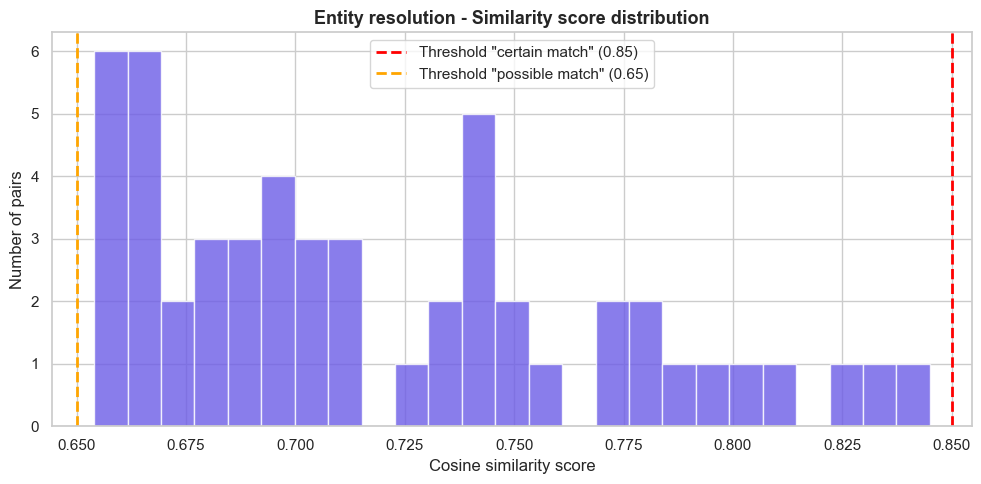

In [80]:
# === MDM: Entity resolution with TF-IDF + cosine similarity ===

print('MASTER DATA MANAGEMENT - Entity resolution')
print('=' * 60)

# Build a composite key for matching
df_mdm = df[['customer_id', 'first_name', 'last_name', 'email', 'phone', 'street', 'postal_code', 'city']].copy()
df_mdm = df_mdm.head(300)  # Sample for demo

# Combine relevant fields into one text per record
df_mdm['match_text'] = (
    df_mdm['first_name'].fillna('') + ' ' +
    df_mdm['last_name'].fillna('') + ' ' +
    df_mdm['email'].fillna('') + ' ' +
    df_mdm['street'].fillna('') + ' ' +
    df_mdm['postal_code'].fillna('') + ' ' +
    df_mdm['city'].fillna('')
).str.lower().str.strip()

# TF-IDF vectorization
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
tfidf_matrix = vectorizer.fit_transform(df_mdm['match_text'])

# Compute cosine similarity matrix
print('Computing cosine similarity matrix...')
sim_matrix = cosine_similarity(tfidf_matrix)

# Find pairs with high similarity
match_threshold = 0.65
matches = []
for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)):
        if sim_matrix[i][j] > match_threshold:
            matches.append({
                'Record_A': df_mdm.iloc[i]['customer_id'],
                'Name_A': f"{df_mdm.iloc[i]['first_name']} {df_mdm.iloc[i]['last_name']}",
                'City_A': df_mdm.iloc[i]['city'],
                'Record_B': df_mdm.iloc[j]['customer_id'],
                'Name_B': f"{df_mdm.iloc[j]['first_name']} {df_mdm.iloc[j]['last_name']}",
                'City_B': df_mdm.iloc[j]['city'],
                'Similarity': round(sim_matrix[i][j], 3),
            })

df_matches = pd.DataFrame(matches).sort_values('Similarity', ascending=False)

print(f"\n{len(df_matches)} match pairs found (similarity > {match_threshold})")
print(f"   Of which {len(df_matches[df_matches['Similarity'] > 0.85])} are very likely the same entity (> 0.85)")

if len(df_matches) > 0:
    print(f"\nTop 15 matches:")
    print(df_matches.head(15).to_string(index=False))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df_matches['Similarity'], bins=25, color='#6c5ce7', edgecolor='white', alpha=0.8)
    ax.axvline(x=0.85, color='red', linestyle='--', linewidth=2, label='Threshold "certain match" (0.85)')
    ax.axvline(x=0.65, color='orange', linestyle='--', linewidth=2, label='Threshold "possible match" (0.65)')
    ax.set_xlabel('Cosine similarity score')
    ax.set_ylabel('Number of pairs')
    ax.set_title('Entity resolution - Similarity score distribution', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

### Hierarchical clustering for record matching

While simple pairwise fuzzy matching works well, **hierarchical agglomerative clustering** provides a more powerful approach for finding groups of related records:

- **Ward linkage**: Minimizes within-cluster variance - all records in a cluster are highly similar to each other
- **Automatic cluster detection**: Unlike K-means, no need to pre-specify the number of clusters in advance
- **Dendrogram**: Build a tree of similarity relationships - zoom in to see fine-grained matches
- **Advantage**: Better for finding groups of 3+ related records that pairwise matching might split or miss


ADVANCED: Hierarchical Clustering for Duplicate Matching

📊 Hierarchical Clustering Results:
   Records: 50
   Clusters found: 7
   Average cluster size: 7.1 records

🔍 Example Clusters (Names that group together):

  Cluster 1 (3 records):
    - Carlo Rodriguez
    - Carlo Rodriguez
    - Carlos  Rodriguez

  Cluster 2 (3 records):
    - Sofi Rossi
    - sofia rossi
    - Sofia Rubben

  Cluster 3 (10 records):
    - jean dupont
    - Merle van der Berg
    - STERRE van den Brand
    - Aaron de Graaf
    - liza van der Laarse
    - Twan van Breugel
    - Joël van der Plas
    - Pierre Marti
    - Boaz van der Linden
    - Aron van Maaren

  Cluster 4 (4 records):
    - Ecrin Bouwhuisen
    - sebastiaan Uphuis
    - Ilse Bastiaense
    - Quinty Brisee

  Cluster 5 (9 records):
    - Lizzy Kramer
    - Luuk Backer
    - Ilse Perck
    - Alicia de Keijzer
    - M. Garcia
    - Lise Mercks
    - Aaliyah Knuf
    - Kick Aarden
    - uLcia Bianchi


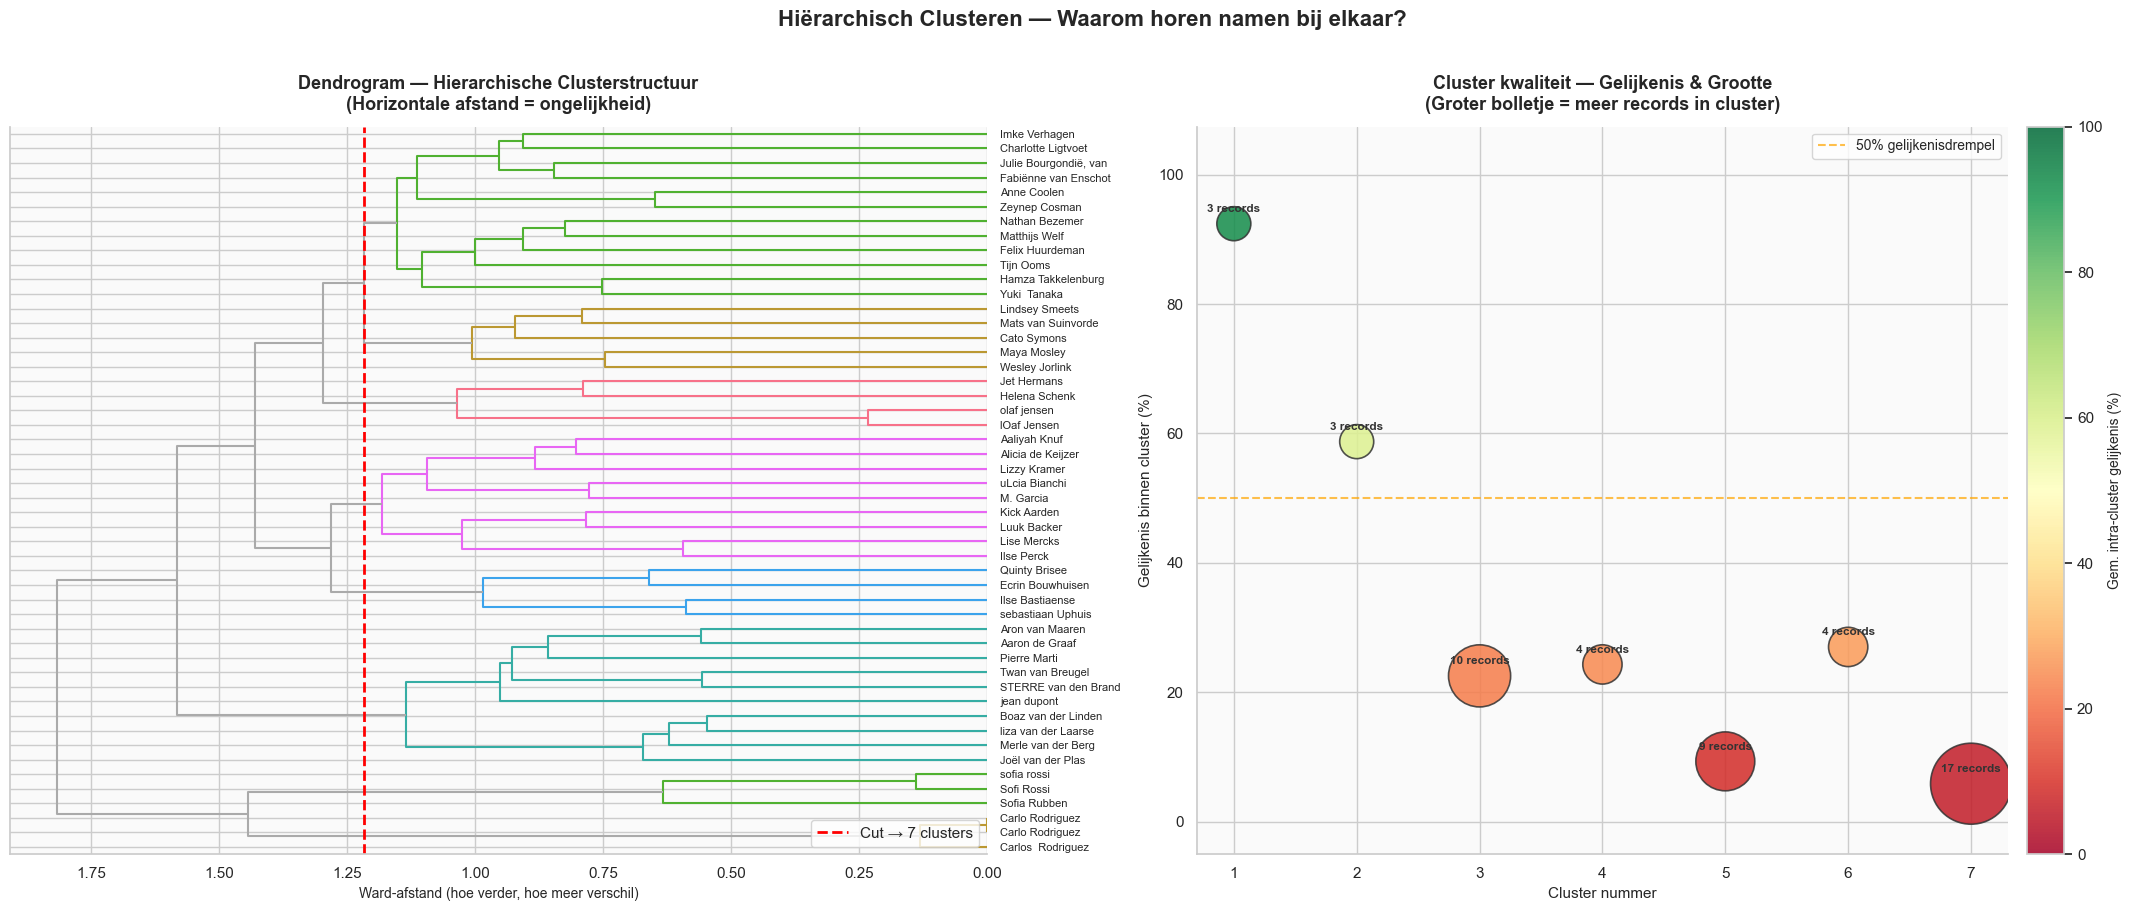


✓ Hierarchical clustering visualisation complete
  Linker figuur  → dendrogram toont hoe namen stap-voor-stap worden samengevoegd
  Rechter figuur → elk bolletje = één cluster; kleur = hoe gelijkend; grootte = #records


In [85]:
# === BONUS: Hierarchical Clustering for Duplicate Detection ===
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

print('\n' + '='*70)
print('ADVANCED: Hierarchical Clustering for Duplicate Matching')
print('='*70)

# ===== CREATE FEATURE MATRIX FOR CLUSTERING =====
sample_mdm = df[['first_name', 'last_name', 'city']].head(50).copy()
sample_mdm['name_combined'] = sample_mdm['first_name'].astype(str) + ' ' + sample_mdm['last_name'].astype(str)

# Compute pairwise TF-IDF distances on combined names (character n-grams)
vectorizer_names = TfidfVectorizer(analyzer='char', ngram_range=(2, 2))
tfidf_names = vectorizer_names.fit_transform(sample_mdm['name_combined'].astype(str))
distance_matrix = cosine_distances(tfidf_names)

# ===== HIERARCHICAL CLUSTERING (Ward's method) =====
n_clusters_hier = int(np.sqrt(len(sample_mdm)))
Z = linkage(squareform(distance_matrix), method='ward')
cluster_labels = fcluster(Z, t=n_clusters_hier, criterion='maxclust')
sample_mdm['cluster_hierarchical'] = cluster_labels

print(f"\n📊 Hierarchical Clustering Results:")
print(f"   Records: {len(sample_mdm)}")
print(f"   Clusters found: {cluster_labels.max()}")
print(f"   Average cluster size: {len(sample_mdm) / cluster_labels.max():.1f} records")

print(f"\n🔍 Example Clusters (Names that group together):")
for cluster_id in sorted(sample_mdm['cluster_hierarchical'].unique())[:5]:
    cluster_records = sample_mdm[sample_mdm['cluster_hierarchical'] == cluster_id]
    if len(cluster_records) > 1:
        print(f"\n  Cluster {cluster_id} ({len(cluster_records)} records):")
        for _, row in cluster_records.iterrows():
            print(f"    - {row['name_combined']}")

# ===== VISUALISATION =====
fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor='white')

# --- LEFT: Dendrogram (the tree) ---
ax_dendro = axes[0]
ax_dendro.set_facecolor('#fafafa')

# Use only leaf labels up to 50 names (already sampled)
leaf_labels = sample_mdm['name_combined'].tolist()

dend = dendrogram(
    Z,
    ax=ax_dendro,
    labels=leaf_labels,
    orientation='left',
    leaf_font_size=8,
    color_threshold=Z[-n_clusters_hier, 2],  # color the n_clusters cut
    above_threshold_color='#aaa',
)

# Draw horizontal cut line to show where clusters split
cut_height = Z[-n_clusters_hier, 2]
ax_dendro.axvline(x=cut_height, color='red', linestyle='--', linewidth=2,
                  label=f'Cut → {n_clusters_hier} clusters')
ax_dendro.legend(fontsize=11, loc='lower right')
ax_dendro.set_title('Dendrogram — Hierarchische Clusterstructuur\n(Horizontale afstand = ongelijkheid)', 
                     fontsize=13, fontweight='bold', pad=12)
ax_dendro.set_xlabel('Ward-afstand (hoe verder, hoe meer verschil)', fontsize=10)
ax_dendro.spines['top'].set_visible(False)
ax_dendro.spines['right'].set_visible(False)

# --- RIGHT: Cluster bubble chart (similarity heatmap for top clusters) ---
ax_heat = axes[1]

# Build cluster summary
cluster_counts = sample_mdm['cluster_hierarchical'].value_counts().sort_index()
cluster_sizes = cluster_counts.values
cluster_ids   = cluster_counts.index.tolist()

# Compute intra-cluster average similarity per cluster
n_vec = tfidf_names.shape[0]
intra_sim = []
for cid in cluster_ids:
    members = sample_mdm[sample_mdm['cluster_hierarchical'] == cid].index.tolist()
    if len(members) < 2:
        intra_sim.append(0.0)
    else:
        sims = [1 - distance_matrix[i, j] for ii, i in enumerate(members) for j in members[ii+1:]]
        intra_sim.append(np.mean(sims) * 100)

# Scatter: x=cluster_id, y=intra_cluster_similarity, size=cluster_size
colors_bubble = plt.cm.RdYlGn(np.array(intra_sim) / 100)
sc = ax_heat.scatter(cluster_ids, intra_sim,
                     s=[sz * 200 for sz in cluster_sizes],
                     c=intra_sim, cmap='RdYlGn', vmin=0, vmax=100,
                     edgecolors='#333', linewidths=1.2, alpha=0.85, zorder=3)

# Annotate with cluster size
for cid, sim, sz in zip(cluster_ids, intra_sim, cluster_sizes):
    ax_heat.text(cid, sim + 1.5, f'{sz} records', ha='center', va='bottom',
                 fontsize=8.5, color='#333', fontweight='bold')

cbar = plt.colorbar(sc, ax=ax_heat, pad=0.02)
cbar.set_label('Gem. intra-cluster gelijkenis (%)', fontsize=10)

ax_heat.set_xlabel('Cluster nummer', fontsize=11)
ax_heat.set_ylabel('Gelijkenis binnen cluster (%)', fontsize=11)
ax_heat.set_title('Cluster kwaliteit — Gelijkenis & Grootte\n(Groter bolletje = meer records in cluster)',
                   fontsize=13, fontweight='bold', pad=12)
ax_heat.set_ylim(-5, max(intra_sim) + 15 if intra_sim else 100)
ax_heat.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
                label='50% gelijkenisdrempel')
ax_heat.legend(fontsize=10)
ax_heat.spines['top'].set_visible(False)
ax_heat.spines['right'].set_visible(False)
ax_heat.set_facecolor('#fafafa')

plt.suptitle('Hiërarchisch Clusteren — Waarom horen namen bij elkaar?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n✓ Hierarchical clustering visualisation complete')
print('  Linker figuur  → dendrogram toont hoe namen stap-voor-stap worden samengevoegd')
print('  Rechter figuur → elk bolletje = één cluster; kleur = hoe gelijkend; grootte = #records')

### 5.2 Golden record creation

After identifying duplicates, we create a **golden record** - the best, most complete version of each entity by applying survivorship rules:

In [82]:
# === MDM: Golden record creation with clustering ===

print('GOLDEN RECORD CREATION - Survivorship rules')
print('=' * 60)

# Use Agglomerative Clustering on the similarity matrix
# Adjust threshold so only high matches are clustered
distance_matrix = 1 - sim_matrix
np.fill_diagonal(distance_matrix, 0)

clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.35,  # 1 - 0.65 similarity
    metric='precomputed',
    linkage='complete'
)
df_mdm['cluster'] = clustering.fit_predict(distance_matrix)

# Show clusters with multiple records (= duplicates)
cluster_sizes = df_mdm['cluster'].value_counts()
dup_clusters = cluster_sizes[cluster_sizes > 1].index.tolist()

print(f"\n{len(dup_clusters)} clusters with possible duplicates found")
print(f"   Total {cluster_sizes[cluster_sizes > 1].sum()} records in duplicate clusters")

# === Survivorship rules for the golden record ===
def create_golden_record(cluster_df):
    """
    Create a golden record from a cluster of duplicates.
    Rules:
    - Name: choose the longest (most complete) version
    - Email: choose the first non-empty value with valid format
    - Phone: choose the longest number (most complete)
    - City: choose the version with proper capitalization
    - Other: choose the most frequent value
    """
    golden = {}
    
    # Name: longest version
    nonnull_first_name = cluster_df['first_name'].dropna()
    golden['first_name'] = nonnull_first_name.loc[nonnull_first_name.str.len().idxmax()] if len(nonnull_first_name) > 0 else None
    
    nonnull_last_name = cluster_df['last_name'].dropna()
    golden['last_name'] = nonnull_last_name.loc[nonnull_last_name.str.len().idxmax()] if len(nonnull_last_name) > 0 else None
    
    # Email: first valid
    for email in cluster_df['email'].dropna():
        if re.match(r'^[\w.-]+@[\w.-]+\.\w{2,}$', str(email)):
            golden['email'] = email
            break
    else:
        golden['email'] = cluster_df['email'].dropna().iloc[0] if len(cluster_df['email'].dropna()) > 0 else None
    
    # Phone: longest version
    nonnull_phone = cluster_df['phone'].dropna().astype(str)
    golden['phone'] = nonnull_phone.loc[nonnull_phone.str.len().idxmax()] if len(nonnull_phone) > 0 else None
    
    # City: version with capitalization
    for city in cluster_df['city'].dropna():
        if str(city)[0].isupper():
            golden['city'] = city
            break
    else:
        golden['city'] = cluster_df['city'].dropna().iloc[0] if len(cluster_df['city'].dropna()) > 0 else None
    
    # Postal code and street: first non-empty
    golden['postal_code'] = cluster_df['postal_code'].dropna().iloc[0] if len(cluster_df['postal_code'].dropna()) > 0 else None
    golden['street'] = cluster_df['street'].dropna().iloc[0] if len(cluster_df['street'].dropna()) > 0 else None
    golden['customer_id'] = cluster_df['customer_id'].iloc[0]
    golden['source_records'] = ', '.join(cluster_df['customer_id'].tolist())
    golden['num_sources'] = len(cluster_df)
    
    return golden

# Create golden records for the first 5 duplicate clusters (demo)
print('\nExample: Golden record creation for first duplicate clusters\n')

golden_records = []
for cluster_id in dup_clusters[:8]:
    cluster_data = df_mdm[df_mdm['cluster'] == cluster_id]
    
    print(f"--- Cluster {cluster_id} ({len(cluster_data)} records) ---")
    print(cluster_data[['customer_id', 'first_name', 'last_name', 'email', 'city']].to_string(index=False))
    
    golden = create_golden_record(cluster_data)
    golden_records.append(golden)
    
    print(f"  Golden record: {golden['first_name']} {golden['last_name']} | {golden['email']} | {golden['city']}")
    print()

# Summary
df_golden = pd.DataFrame(golden_records)
print(f"\n{'='*60}")
print('MDM SUMMARY:')
print(f"   Records before deduplication:  {len(df_mdm)}")
n_gededup = len(df_mdm) - sum(cluster_sizes[cluster_sizes > 1] - 1)
print(f"   Records after deduplication:   {n_gededup}")
print(f"   Duplicates removed:            {len(df_mdm) - n_gededup}")
print(f"   Golden records created:        {len(golden_records)}")

GOLDEN RECORD CREATION - Survivorship rules

14 clusters with possible duplicates found
   Total 40 records in duplicate clusters

Example: Golden record creation for first duplicate clusters

--- Cluster 0 (5 records) ---
customer_id first_name last_name                      email       city
    KL-2044      Carlo Rodriguez  carlo.rodriguez@gmail.com    Haarlem
    KL-2038      Carlo Rodriguez  carlo.rodriguez@gmail.com     Zwolle
    KL-2041    Carlos  Rodriguez carlos.rodriguez@gmail.com  Eindhoven
    KL-2040     carlos rodriguez carlos.rodriguez@gmail.com Amersfoort
    KL-2039     Carlos  Rodrigue  carlos.rodrigue@gmail.com      Breda
  Golden record: Carlos  Rodriguez | carlo.rodriguez@gmail.com | Haarlem

--- Cluster 4 (4 records) ---
customer_id first_name last_name                  email       city
    KL-2011     Maria     Garcia maria.garcia@gmail.com      Breda
    KL-2010      maria    garcia maria.garcia@gmail.com     Leiden
    KL-2008       Mari    Garcia  mari.garcia@

### 5.3 Automated standardization

AI can automatically correct city names by matching them against a reference list. This turns "Amstterdam" into "Amsterdam":

AUTOMATED STANDARDIZATION

CITY NAME CORRECTIONS (5 unique corrections found):

  Original  Corrected  Fuzzy Score Correction type
 AMSTERDAM  Amsterdam          100            Typo
maastricht Maastricht          100            Typo
  Roterdam  Rotterdam           94            Typo
 eindhoven  Eindhoven          100            Typo
 ROTTERDAM  Rotterdam          100            Typo


PROVINCE ENRICHMENT (derived from postal code):

customer_id       city city_corrected  match_score postal_code      province
    KL-1078 Amersfoort     Amersfoort        100.0     2677 KJ  Zuid-Holland
    KL-2089  Amsterdam      Amsterdam        100.0         NaN          None
    KL-1152  Groningen      Groningen        100.0      8403LL     Friesland
    KL-1281    Tilburg        Tilburg        100.0      9375SH     Groningen
    KL-2044    Haarlem        Haarlem        100.0      8976IU     Friesland
    KL-2046     Leiden         Leiden        100.0      1616DU     Flevoland
    KL-1237  Amsterdam  

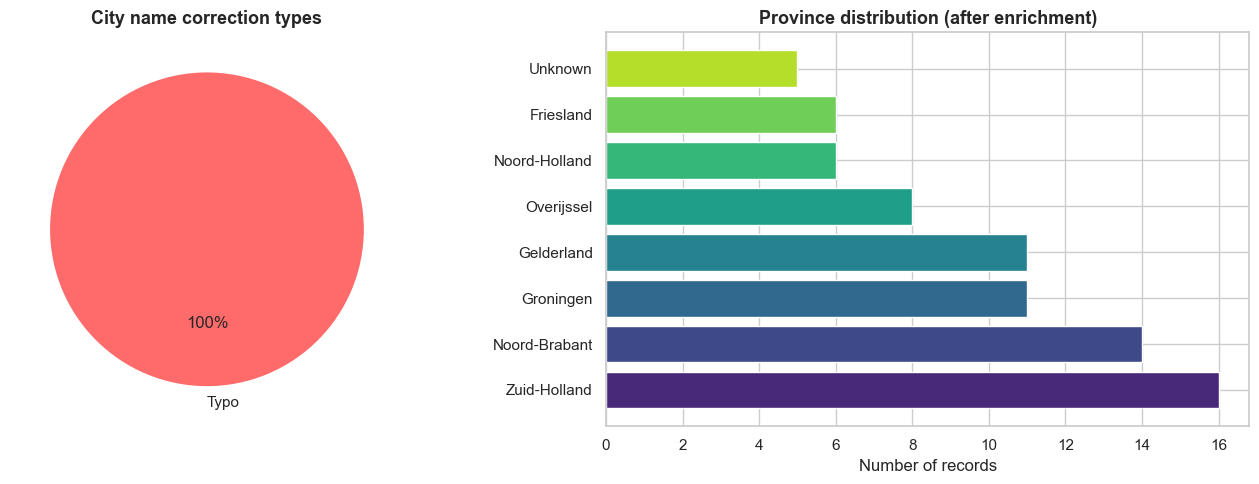

In [83]:
# === MDM: Automated standardization ===

print('AUTOMATED STANDARDIZATION')
print('=' * 60)

# Reference list of Dutch cities
reference_cities = ['Amsterdam', 'Rotterdam', 'Utrecht', 'Den Haag', 'Eindhoven',
                    'Groningen', 'Tilburg', 'Almere', 'Breda', 'Nijmegen',
                    'Arnhem', 'Haarlem', 'Leiden', 'Maastricht', 'Zwolle',
                    "'s-Gravenhage", 'Delft', 'Enschede', 'Apeldoorn', 'Amersfoort']

# Postal code to province mapping (simplified)
postcode_province = {
    '10': 'Noord-Holland', '11': 'Noord-Holland', '12': 'Noord-Holland', '13': 'Noord-Holland',
    '14': 'Noord-Holland', '15': 'Noord-Holland', '16': 'Flevoland',
    '20': 'Zuid-Holland', '21': 'Zuid-Holland', '22': 'Zuid-Holland', '23': 'Zuid-Holland',
    '24': 'Zuid-Holland', '25': 'Zuid-Holland', '26': 'Zuid-Holland', '27': 'Zuid-Holland',
    '28': 'Zuid-Holland', '29': 'Zuid-Holland',
    '30': 'Utrecht', '31': 'Utrecht', '34': 'Utrecht', '35': 'Utrecht',
    '36': 'Utrecht', '37': 'Utrecht', '38': 'Overijssel', '39': 'Overijssel',
    '40': 'Noord-Brabant', '41': 'Noord-Brabant', '42': 'Noord-Brabant',
    '43': 'Noord-Brabant', '44': 'Noord-Brabant', '45': 'Noord-Brabant',
    '46': 'Noord-Brabant', '47': 'Noord-Brabant', '48': 'Noord-Brabant',
    '49': 'Noord-Brabant', '50': 'Noord-Brabant', '51': 'Noord-Brabant',
    '52': 'Noord-Brabant', '53': 'Noord-Brabant', '54': 'Noord-Brabant',
    '55': 'Noord-Brabant', '56': 'Zeeland', '57': 'Zeeland',
    '60': 'Limburg', '61': 'Limburg', '62': 'Limburg', '63': 'Limburg',
    '64': 'Limburg', '65': 'Gelderland', '66': 'Gelderland',
    '67': 'Gelderland', '68': 'Gelderland', '69': 'Gelderland',
    '70': 'Gelderland', '71': 'Gelderland', '72': 'Overijssel',
    '73': 'Overijssel', '74': 'Overijssel', '75': 'Overijssel',
    '76': 'Overijssel', '77': 'Drenthe', '78': 'Drenthe',
    '79': 'Drenthe', '80': 'Overijssel', '81': 'Overijssel',
    '82': 'Flevoland', '83': 'Friesland', '84': 'Friesland',
    '85': 'Friesland', '86': 'Friesland', '87': 'Friesland',
    '88': 'Friesland', '89': 'Friesland',
    '90': 'Groningen', '91': 'Groningen', '92': 'Groningen',
    '93': 'Groningen', '94': 'Groningen', '95': 'Groningen',
    '96': 'Groningen', '97': 'Drenthe', '98': 'Drenthe', '99': 'Drenthe',
}

# 1. City name correction with fuzzy matching
df_std = df[['customer_id', 'city', 'postal_code', 'phone']].dropna(subset=['city']).head(100).copy()
corrections = []

for idx, row in df_std.iterrows():
    city_orig = str(row['city'])
    best_match, score = process.extractOne(city_orig, reference_cities, scorer=fuzz.ratio)
    
    if city_orig != best_match and score > 70:
        corrections.append({
            'Original': city_orig,
            'Corrected': best_match,
            'Fuzzy Score': score,
            'Correction type': 'Typo' if score > 85 else 'Capitalization' if city_orig.lower() == best_match.lower() else 'Variation'
        })
    df_std.loc[idx, 'city_corrected'] = best_match
    df_std.loc[idx, 'match_score'] = score

# 2. Province enrichment
def postcode_to_province(pc):
    if pd.isna(pc): return None
    prefix = str(pc).strip()[:2]
    return postcode_province.get(prefix, 'Unknown')

df_std['province'] = df_std['postal_code'].apply(postcode_to_province)

# 3. Show corrections
df_corrections = pd.DataFrame(corrections).drop_duplicates()
if len(df_corrections) > 0:
    print(f"\nCITY NAME CORRECTIONS ({len(df_corrections)} unique corrections found):\n")
    print(df_corrections.to_string(index=False))

# 4. Show enrichment
print(f"\n\nPROVINCE ENRICHMENT (derived from postal code):\n")
print(df_std[['customer_id', 'city', 'city_corrected', 'match_score', 'postal_code', 'province']].head(15).to_string(index=False))

# Visualization of corrections
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# City names before/after
if len(df_corrections) > 0:
    corr_types = df_corrections['Correction type'].value_counts()
    ax1.pie(corr_types.values, labels=corr_types.index, autopct='%1.0f%%',
            colors=['#ff6b6b', '#ffd93d', '#74c0fc'], startangle=90)
    ax1.set_title('City name correction types', fontsize=13, fontweight='bold')

# Province distribution
prov_counts = df_std['province'].value_counts().head(8)
ax2.barh(prov_counts.index, prov_counts.values, color=sns.color_palette('viridis', len(prov_counts)))
ax2.set_xlabel('Number of records')
ax2.set_title('Province distribution (after enrichment)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
# Summary: AI Data Management Maturity Dashboard

We conclude with a visual overview of all five themes - including key findings and the impact of AI support. This is the executive summary of our analysis.

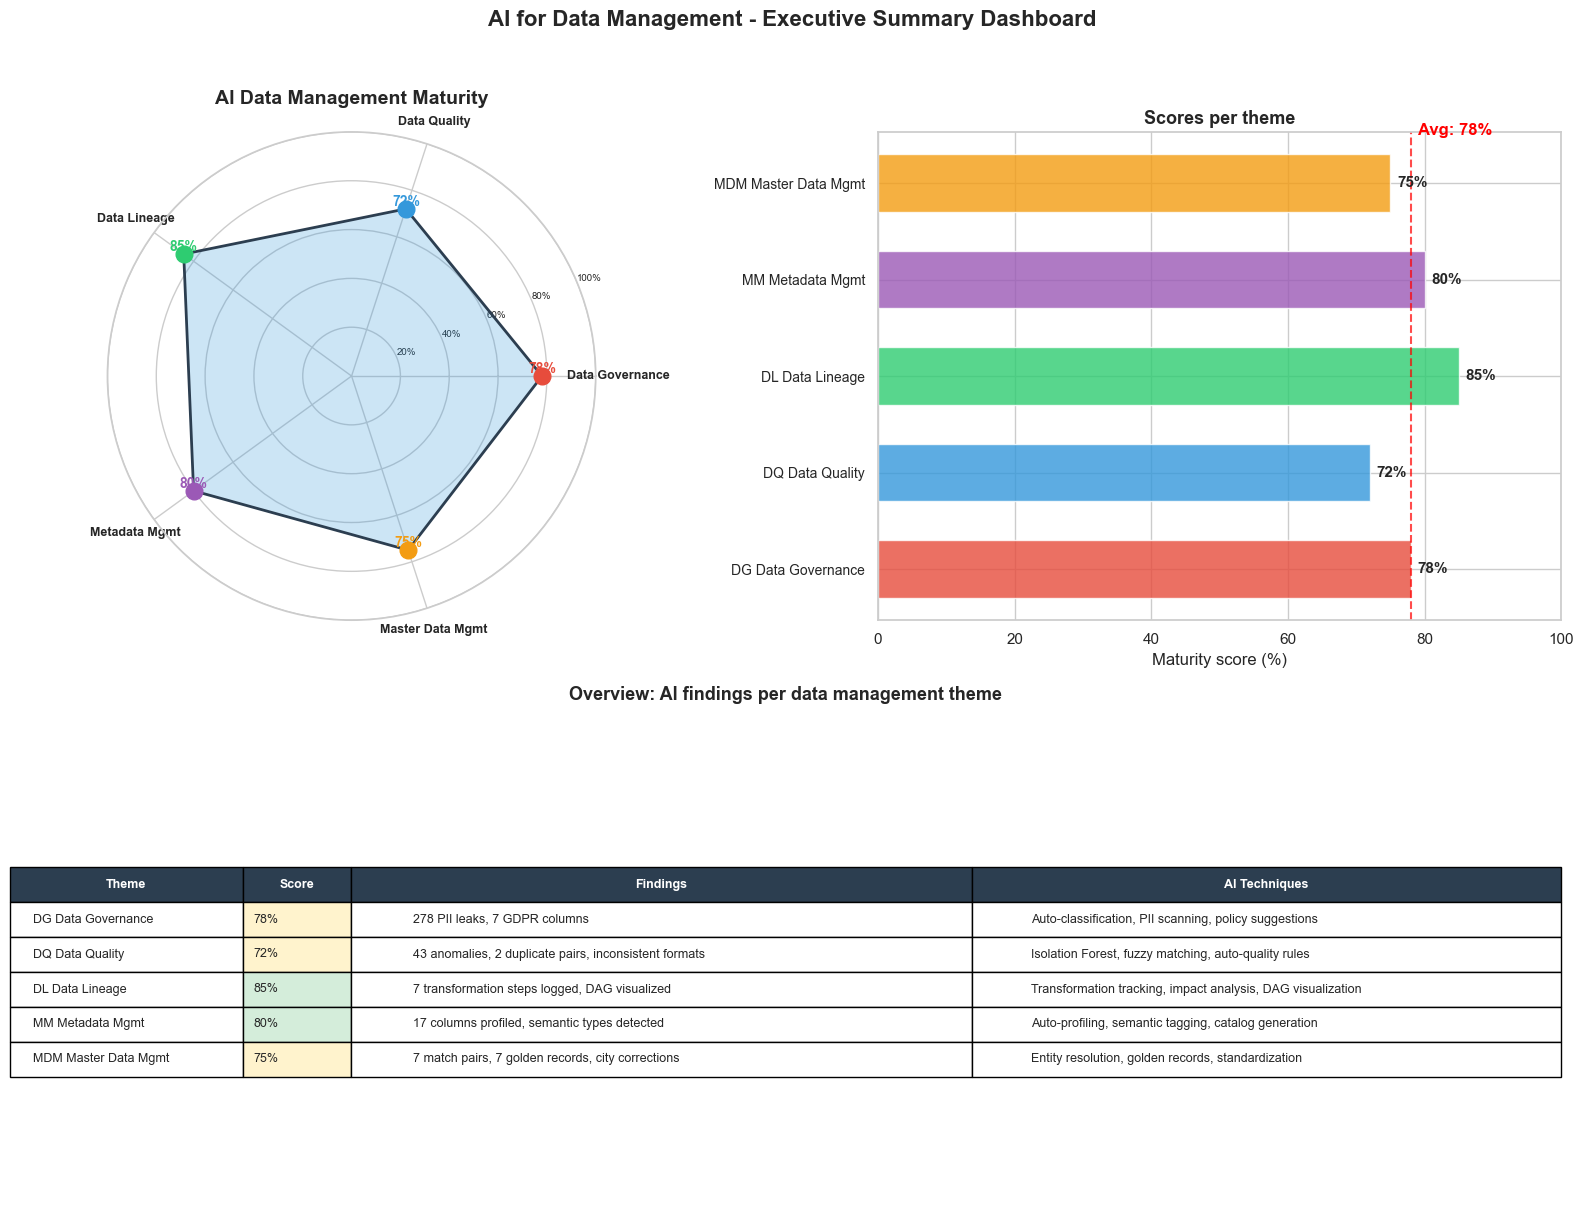

In [29]:
# === DASHBOARD: AI Data Management Maturity Overview ===

# Summary data per theme
themes = {
    'Data Governance': {
        'score': 78,
        'color': '#e74c3c',
        'found': f"{sum(pii_results.values())} PII leaks, {len(df_class[df_class['gdpr_relevant']==True])} GDPR columns",
        'ai_action': 'Auto-classification, PII scanning, policy suggestions',
        'icon': 'DG',
    },
    'Data Quality': {
        'score': 72,
        'color': '#3498db',
        'found': f"{n_anomalies} anomalies, {len(df_duplicates)} duplicate pairs, inconsistent formats",
        'ai_action': 'Isolation Forest, fuzzy matching, auto-quality rules',
        'icon': 'DQ',
    },
    'Data Lineage': {
        'score': 85,
        'color': '#2ecc71',
        'found': f"{len(tracker.lineage_log)} transformation steps logged, DAG visualized",
        'ai_action': 'Transformation tracking, impact analysis, DAG visualization',
        'icon': 'DL',
    },
    'Metadata Mgmt': {
        'score': 80,
        'color': '#9b59b6',
        'found': f"{len(profiles)} columns profiled, semantic types detected",
        'ai_action': 'Auto-profiling, semantic tagging, catalog generation',
        'icon': 'MM',
    },
    'Master Data Mgmt': {
        'score': 75,
        'color': '#f39c12',
        'found': f"{len(df_matches)} match pairs, {len(golden_records)} golden records, city corrections",
        'ai_action': 'Entity resolution, golden records, standardization',
        'icon': 'MDM',
    }
}

# === RADAR / SPIDER CHART ===
fig = plt.figure(figsize=(16, 12))

# Subplot 1: Radar chart
ax1 = fig.add_subplot(221, polar=True)
labels = list(themes.keys())
scores = [t['score'] for t in themes.values()]
colors = [t['color'] for t in themes.values()]

# Close the polygon
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
scores_plot = scores + [scores[0]]
angles_plot = angles + [angles[0]]

ax1.plot(angles_plot, scores_plot, 'o-', linewidth=2, color='#2c3e50')
ax1.fill(angles_plot, scores_plot, alpha=0.25, color='#3498db')

for angle, score, color in zip(angles, scores, colors):
    ax1.plot(angle, score, 'o', markersize=12, color=color, zorder=5)
    ax1.annotate(f'{score}%', xy=(angle, score), fontsize=10, fontweight='bold',
                ha='center', va='bottom', color=color)

ax1.set_thetagrids(np.degrees(angles), labels, fontsize=9, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_yticks([20, 40, 60, 80, 100])
ax1.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7)
ax1.set_title('AI Data Management Maturity', fontsize=14, fontweight='bold', pad=20)

# Subplot 2: Bar chart per theme
ax2 = fig.add_subplot(222)
y_pos = range(len(labels))
bars = ax2.barh(y_pos, scores, color=colors, alpha=0.8, edgecolor='white', height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{themes[l]['icon']} {l}" for l in labels], fontsize=10)
ax2.set_xlabel('Maturity score (%)')
ax2.set_xlim(0, 100)
ax2.set_title('Scores per theme', fontsize=13, fontweight='bold')

for bar, score in zip(bars, scores):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{score}%', va='center', fontweight='bold', fontsize=11)

# Average line
avg = np.mean(scores)
ax2.axvline(x=avg, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(avg + 1, len(labels)-0.5, f'Avg: {avg:.0f}%', color='red', fontweight='bold')

# Subplot 3: Summary table
ax3 = fig.add_subplot(212)
ax3.axis('off')

table_data = []
for name, info in themes.items():
    table_data.append([
        f"{info['icon']} {name}",
        f"{info['score']}%",
        info['found'],
        info['ai_action']
    ])

table = ax3.table(
    cellText=table_data,
    colLabels=['Theme', 'Score', 'Findings', 'AI Techniques'],
    cellLoc='left',
    colWidths=[0.15, 0.07, 0.40, 0.38],
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Header colors
for j in range(4):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Score cell colors
for i, score in enumerate(scores):
    if score >= 80:
        table[i+1, 1].set_facecolor('#d4edda')
    elif score >= 70:
        table[i+1, 1].set_facecolor('#fff3cd')
    else:
        table[i+1, 1].set_facecolor('#f8d7da')

ax3.set_title('Overview: AI findings per data management theme',
              fontsize=13, fontweight='bold', pad=20)

plt.suptitle('AI for Data Management - Executive Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Conclusion and Discussion

## What did we see?

| Theme | Key Takeaway |
|-------|-------------|
| **Data Governance** | AI can automatically classify sensitive data and detect PII leaks - including in unexpected places like free text fields |
| **Data Quality** | Machine learning (Isolation Forest) finds anomalies missed by manual review; fuzzy matching detects duplicates with variations |
| **Data Lineage** | Automatic tracking and visualization of data transformations enables impact analysis - crucial for change management |
| **Metadata Management** | AI can recognize semantic types, tag columns, and generate a complete data catalog without manual work |
| **Master Data Management** | Entity resolution with TF-IDF + cosine similarity finds the same customer despite name variations; golden records create a single source of truth |

## Key insights for practice

1. **AI does not replace data management** - it strengthens it. Human expertise remains essential for policy decisions.
2. **Data does not need to be perfect** to start with AI - imperfect data is exactly where AI proves its value.
3. **Start small**: begin with one theme (e.g., data quality) and expand from there.
4. **Transparency is essential**: AI must explain *why* something is flagged as an anomaly or duplicate (confidence scores).
5. **Combine techniques**: the power is in combining rule-based and ML-based approaches.

## Discussion questions
- Which theme would deliver the most value in your organization?
- Where do you see the biggest barriers to adoption?
- How do you balance "AI speed" versus "human control"?

---
This notebook supports a lecture on AI and Data Management. The code is for demonstration and can be a starting point for your own implementations.